# Introduction

This notebook presents a multi-scenario analysis of the carbon saving achieved by the scheduler under different circumstances.

First of all, we aim to evaluate various policies:
- `baseline`: the baseline algorithm, which schedules requests with the most accurate flavour as they arrive, without considering carbon intensity or cap levels.
- **Carbonshift**: our scheduler running carbonshift with different batch sizes. This presents two possible fallback policies to deal with infeasibility (no assignment yields a feasible solution with respect to the error threshold):
  - `min_error_greedy` (*"greedy fallback"*): scheduler uses only the *Accurate* flavour, placing requests in the slots with the lowest carbon intensity, until the error threshold is reached. 
  - `carryover`: the scheduler will consider the previous slot's amount of assigned requests as reference, assuming that about the same amount of requests will arrive in the current slot. This relaxes the error threshold, avoiding to "panick" when the window shifts (which may lead to infeasibility).
    - Actually only a portion (e.g. 80%) of the previous slot's assigned requests is considered, to avoid overestimating the current slot's amount of requests, and if infeasibility is  still present on the next window movement, the portion decreases further by a fixed amount (e.g. 20%) until it reaches 0%.
    - Even though unlikely, this policy falls back to `min_error_greedy` if infeasibility persists after injecting the carryover amount of requests.
- **Online policies**
  - `greedy_singleton`: as requests arrive, for each request, use the cheapest flavour allowed by the error threshold, find the cheapest slot for each request as it arrives, taking into account the current slot's carbon intensity and the cap level. If infeasibility occurs, *greedy fallback* is applied.
    - This is analogous to **carbonshift** with batch size 1, but is simpler in the implementation.
    - Note that the amount of possible assignments is rather low: for 14 window slots and 3 flavours, there are only 42 possible assignments for each request.
  - **Swarm policies**
    - `ant_colony`: the ant colony optimization algorithm, which benefits from higher batch sizes, as it can solver bigger subproblems and find better suboptimal solutions, exploring a wider space of solutions. 
    - (Multi-armed) `bandit`: the multi-armed bandit algorithm, which balances exploration and exploitation to find good assignments over time. The online version does not exhibit a strong degradation with respect to the offline version.
- **Offline policies**\
These are the same as the online policies, but are executed offline, and are used only as a reference for testing.
  - `greedy_cheapest`: same as `greedy_singleton` above, but in an offline single threaded fashion, no concurrency occurs.
  - `ant_colony`: same as above, but in an offline single threaded fashion, no concurrency occurs. Having the entire window available, the ant colony algorithm can find better solutions than in the online version. A solution represents the assignment of all requests, opposed to finding the best assignment for N requests at a time, as in the online version.
  - `bandit`: same as above, but in an offline single threaded fashion, no concurrency occurs. Here, bandit the exploration/exploitation tradeoff applies in the same way as in the online version.

*Note:* names in `backticks` are the same names used in the dataframe tables displayed below; do not expect to read "DP-solver" or "carbonshift" there; `carryover` and `min_error_greedy` refer to the carbonshift solver, only distinguishing the fallback policy.


## Information on the tests

Tests are conducted over two main **scenarios**:
  - `high_load_1500_92`: scenario with (on average) 1500 requests per slot (randomness seed `92`) 
  - `xhigh_load_2000_120`: scenario with (on average) 2000 requests per slot (randomness seed `120`) 

The maximum **deadline** slack for requests is set to 14 slots, matching the future window for possible assignments, which is also 14 slots.\
Time slots are meant to be considered **hourly**, so that each slot represents one hour.\
Given that the carbon intensity pattern presents peaks and valleys every 12 hours following the light and dark cycles of the day, with 14 hourly slots, the scheduling of requests can take advantage of the whole variation of the pattern, always seeing both a valley and a peak (not two valleys nor two peaks).\
Using 30min slots (as in previous Carbonshift literature) would double the number of slots in the same 14-hour window to still be able to exploit CI variations, making the tests even more computationally intensive. For testing purposes, we can stick to hourly slots.

The moving **window** is `[-12,+14]` plus another 12 slots in the past with decaying weights applied (from 12/13 to 1/13).
The average error must be kept below the threshold (`4.0` unless otherwise specified), both globally and within each moving window.

Three execution **flavours** are considered:
| flavour | error | exec time |
|---------|-------|-----------|
| Accurate | 0.0 | 60s |
| Balanced | 2.5 | 30s |
| Fast  | 5.0 | 10s |

Beam **pruning** with 1200 retained states is applied where `batch_size >= 8`.

### Metrics

The primary metrics used to evaluate the performance of the scheduling policies are:
- `carbon_saving`: measures the reduction in carbon emissions achieved by the scheduling policy.
- `solver_time_ms_avg`: the average time taken by the solver to compute the schedule, in milliseconds.
- `elapsed_seconds`: the total elapsed time for the scheduling process, in seconds, accounting also for any overhead outside the solver computation.

There are some execution parameters which have been varied in the experiments, in order to study their impact on the performance metrics. These include:
- `parallelism`: the number of parallel solver threads used by the scheduler.
- `batch_size`: the number of requests processed in each batch by the scheduler.
- `RB_max_consecutive`: the maximum number of consecutive rollbacks allowed during the scheduling process.
  - Recall: rollback is applied when, due to stale data in case of parallelism, different threads make assignments which lead to unexpectedly exceeding a cap level in some time slot.
- `threshold`: error threshold applied both globally and within each moving window.

In [20]:
from pathlib import Path
import json
import pandas as pd
import re

import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os
REPO_ROOT = Path().resolve()
RESULTS_DIR = REPO_ROOT / "results"

In [21]:
# this loads and aggregates the battery test results
# disable output for this cell

f = open(os.devnull, 'w')
sys.stdout = f
sys.stderr = f
from save_results import aggregate_and_save
aggregate_and_save(prefix_regex=r"^(cfg)_test(1|2|3|4|5|6|7|8|9|10|11|12|13|14)_")

# Re-enable output
sys.stdout = sys.__stdout__
sys.stderr = sys.__stderr__

In [38]:
# Load csv file 
output_csv = RESULTS_DIR / "aggregated_battery_results.csv"
df_all = pd.read_csv(output_csv)

# if present, rename infeasibility_mode column to "policy"
if "infeasibility_mode" in df_all.columns:
    df_all = df_all.rename(columns={"infeasibility_mode": "policy"})

# display all columns option
pd.set_option("display.max_columns", None)

# filter out runs whose path contains test1_, since test2 is with varying threshold
df = df_all[df_all["path"].str.contains("cfg_test1_")]


# display only 5 rows to get a sample
# Note: this has been comprehensively examined manually. 
#       Visualization will be done in subsequent cells.
pd.set_option("display.max_rows", 5)
display(df.sort_values(by=["scenario_id", "policy", "batch_size","final_global_error", "parallelism","RB_max_consecutive","batch_size"]))

,run_id,scenario_id,requests_in,batch_size,policy,parallelism,solver_time_ms_avg,elapsed_seconds,carbon_cost,carbon_saving,req_assigned_with_GF,total_RBs,peak_consecutive_RBs,RB_max_consecutive,peak_concurrent_workers,avg_concurrent_workers,online_swarm_mode,baseline_carbon_cost,final_global_error,avg_global_error_per_slot,path
211,cfg,high_load_1500_92,107064,1,carryover,1,4.91,655.40,66870.19,68.77,98,0,0,0,1,1.00,merge,214108.17,4.00,4.00,cfg_test1_dp_0_0819_1138_1_roll0_0_F_M/high_lo...
171,cfg,high_load_1500_92,107064,1,carryover,8,15.08,496.70,69874.95,67.36,1453,0,0,0,8,5.77,merge,214108.17,4.00,4.00,cfg_test1_dp_0_0816_2106_8_roll0_0_F_M/high_lo...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417,cfg,xhigh_load_2000_120,144963,1,online_greedy_singleton,8,20.56,959.46,126398.30,64.96,0,131,1,8,8,6.10,merge,360701.75,3.98,3.98,cfg_test1_greedy_singleton_4_0819_0100_8_roll8...
413,cfg,xhigh_load_2000_120,144963,1,online_greedy_singleton,8,20.48,1016.04,123384.27,65.79,0,109,1,4,8,5.92,merge,360701.75,3.99,3.98,cfg_test1_greedy_singleton_2_0819_0008_8_roll4...


## Purpose
Our intent is to assess the performance of different scheduling policies in terms of `carbon_saving`, `solver_time_ms_avg`, and `elapsed_seconds`, and see how different parameters, such as `batch_size` and `parallelism`, affect such performance, in order to identify the most effective configurations in this simulated environment.

`carbon_saving` and `solver_time_ms_avg`/`elapsed_seconds` are the primary metrics since they represent the effectiveness against the cost of the scheduling process.\
Clearly, execution time (especially `elapsed_seconds`) may be affected by other unforeseen factors.

## Visualization
```
"carbon_saving","solver_time_ms_avg","elapsed_seconds"
```

We want to analyze these fields `carbon_saving`,`solver_time_ms_avg`,`elapsed_seconds`.
We must visualize but separating on policys.
The X axis will be the `batch_size` and the Y axis will be the value of the field we are analyzing.


Given that there are multiple runs, we will use the average value of the field for each `batch_size` and `policy` to provide a visual representation.

We will stick to **online policies** evaluation for now.
**Offline policies** work better in general but are there just for reference, as they are not applicable in real-time scenarios.


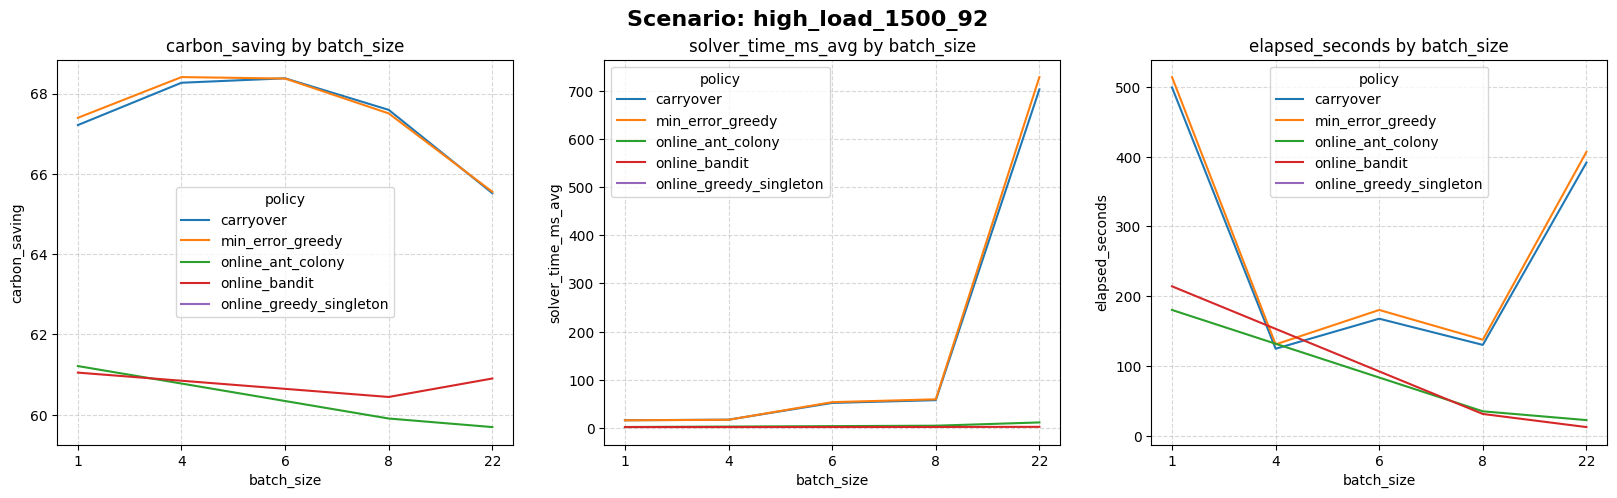

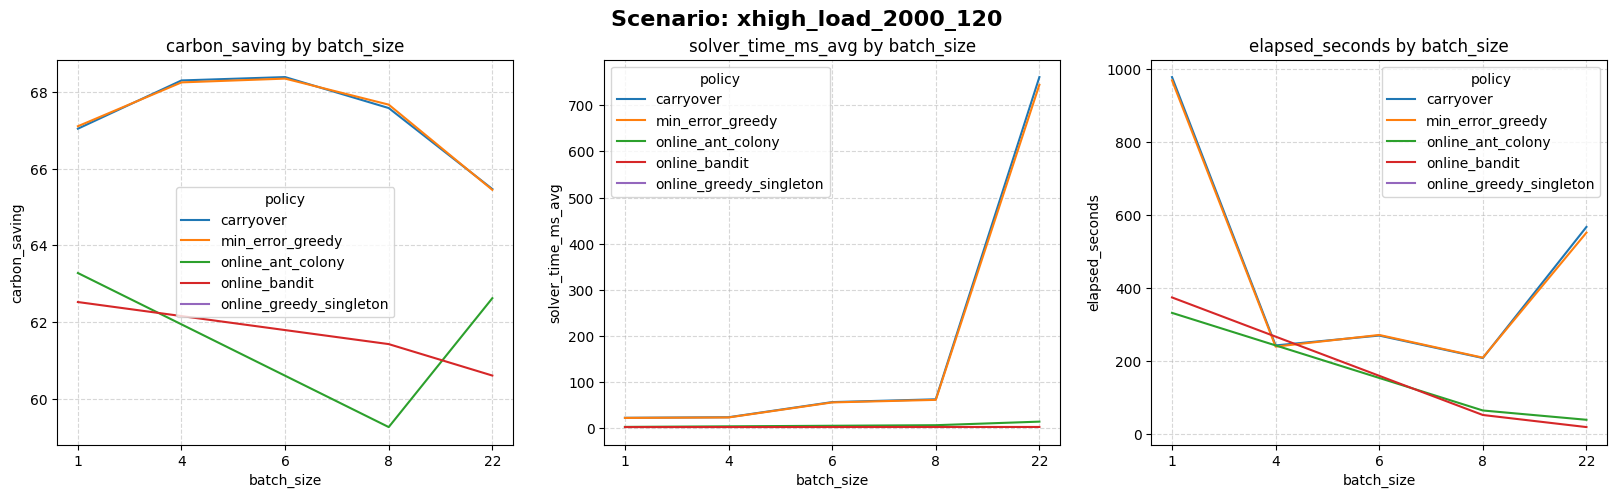

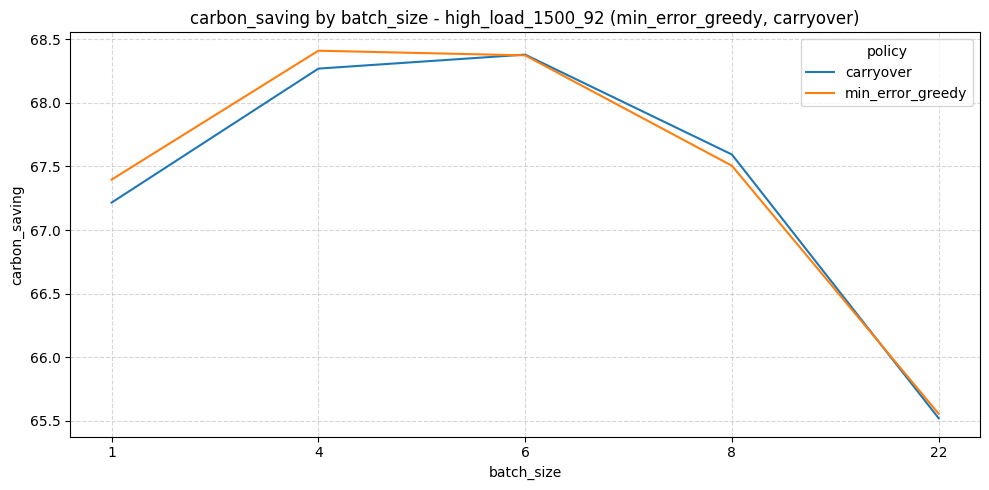

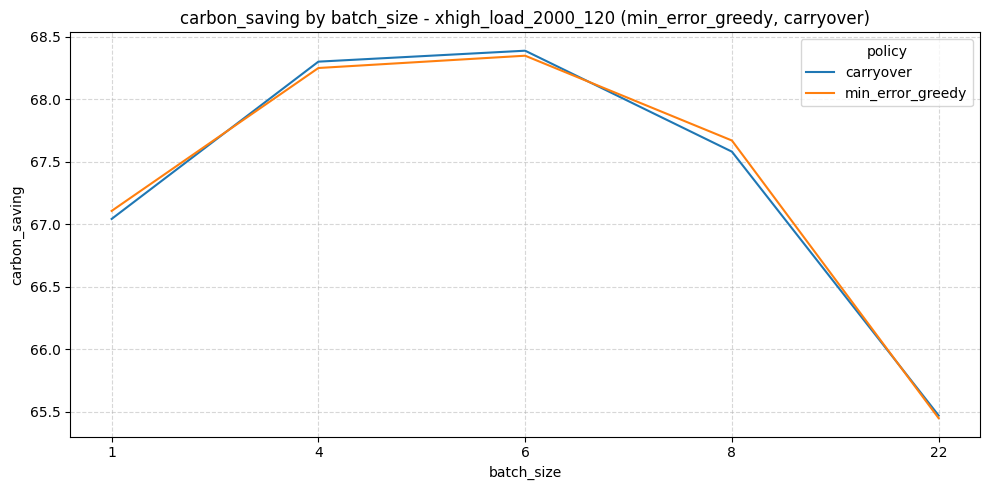

In [39]:
# Work on a clean dataframe
plot_df = df.copy()
plot_df["batch_size"] = pd.to_numeric(plot_df["batch_size"], errors="coerce")
plot_df = plot_df.dropna(subset=["batch_size", "policy"]).copy()

def three_subplots_figure(plot_df, scenario_id, metrics):
    scenario_df = plot_df[plot_df["scenario_id"] == scenario_id].copy()
    fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5))
    if len(metrics) == 1:
        axes = [axes]

    # Set the global title for the figure
    fig.suptitle(f"Scenario: {scenario_id}", fontsize=16, fontweight="bold")

    x_order = sorted(scenario_df["batch_size"].dropna().unique().tolist())
    x_map = {v: i for i, v in enumerate(x_order)}

    for ax, metric in zip(axes, metrics):
        grouped = (
            scenario_df.groupby(["batch_size", "policy"], as_index=False)[metric]
            .mean()
            .sort_values(["policy", "batch_size"])
        ).copy()
        grouped["x_pos"] = grouped["batch_size"].map(x_map)

        sns.lineplot(
            data=grouped,
            x="x_pos",
            y=metric,
            hue="policy",
            markers=True,
            dashes=True,
            errorbar=None,
            ax=ax,
            sort=False,
        )
        ax.set_title(f"{metric} by batch_size")
        ax.set_xlabel("batch_size")
        ax.set_ylabel(metric)
        ax.set_xticks(range(len(x_order)))
        ax.set_xticklabels([str(v) for v in x_order])
        ax.grid(True, linestyle="--", alpha=0.5)

    # Adjust the layout to make room for the global title
    plt.tight_layout(rect=[0, 0, 1, 0.1])
    plt.show()


def special_modes_figure(plot_df, scenario_id, special_modes):
    special_df = plot_df[
        (plot_df["scenario_id"] == scenario_id) &
        (plot_df["policy"].isin(special_modes))
    ].copy()

    x_order = sorted(special_df["batch_size"].dropna().unique().tolist())
    x_map = {v: i for i, v in enumerate(x_order)}
    grouped = (
        special_df.groupby(["batch_size", "policy"], as_index=False)["carbon_saving"]
        .mean()
        .sort_values(["policy", "batch_size"])
    ).copy()
    grouped["x_pos"] = grouped["batch_size"].map(x_map)

    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=grouped,
        x="x_pos",
        y="carbon_saving",
        hue="policy",
        markers=True,
        dashes=True,
        errorbar=None,
        sort=False,
    )
    plt.title(f"carbon_saving by batch_size - {scenario_id} ({', '.join(special_modes)})")
    plt.xlabel("batch_size")
    plt.ylabel("carbon_saving")
    plt.xticks(range(len(x_order)), [str(v) for v in x_order])
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# Three subplots for each scenario
for scenario_id in sorted(plot_df["scenario_id"].unique()):
    three_subplots_figure(plot_df, scenario_id=scenario_id, metrics=["carbon_saving", "solver_time_ms_avg", "elapsed_seconds"])

# Separate plot for carbon_saving limited to min_error_greedy and carryover, one figure per scenario
for scenario_id in sorted(plot_df["scenario_id"].unique()):
    special_modes_figure(plot_df, scenario_id=scenario_id, special_modes=["min_error_greedy", "carryover"])



#### Focus on carbonshift solver with `[4,6,8]` batch sizes
Let's narrow this down a little bit.\
Examine *average*, *min*, *max* values for `carbon_saving` and `elapsed_seconds` with `batch_size` in `[4,6,8]` and `policy` in `["min_error_greedy", "carryover"]`

,scenario_id,policy,batch_size,carbon_saving_avg,carbon_saving_min,carbon_saving_max,elapsed_seconds_avg,elapsed_seconds_min,elapsed_seconds_max
0,high_load_1500_92,carryover,4,68.270000,67.90,69.32,125.050833,104.45,204.88
1,high_load_1500_92,carryover,6,68.380000,67.91,69.38,168.031667,133.54,473.20
2,high_load_1500_92,carryover,8,67.594167,66.67,69.81,130.556667,101.84,379.14
3,high_load_1500_92,min_error_greedy,4,68.410833,68.08,69.35,131.288333,106.99,239.44
4,high_load_1500_92,min_error_greedy,6,68.374167,67.79,69.66,180.546667,131.14,570.99
5,high_load_1500_92,min_error_greedy,8,67.505833,66.42,69.80,137.930833,98.60,426.26
6,xhigh_load_2000_120,carryover,4,68.300833,67.93,69.40,242.566667,215.84,384.21
7,xhigh_load_2000_120,carryover,6,68.388333,68.01,69.96,269.560833,218.97,656.50
8,xhigh_load_2000_120,carryover,8,67.580833,66.90,70.12,207.990833,166.76,531.29
9,xhigh_load_2000_120,min_error_greedy,4,68.250000,67.85,69.65,239.234167,201.61,370.95


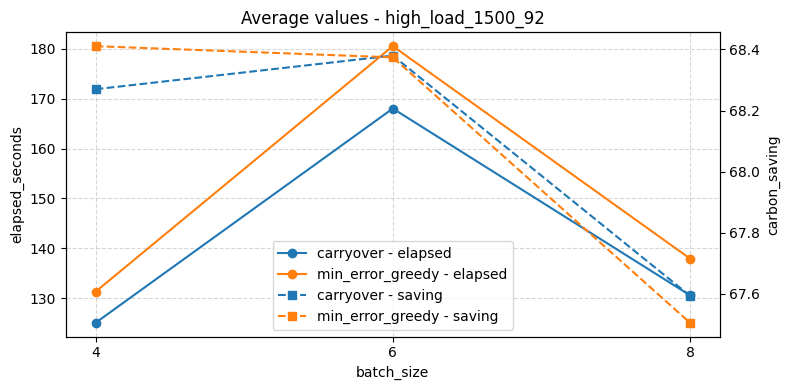

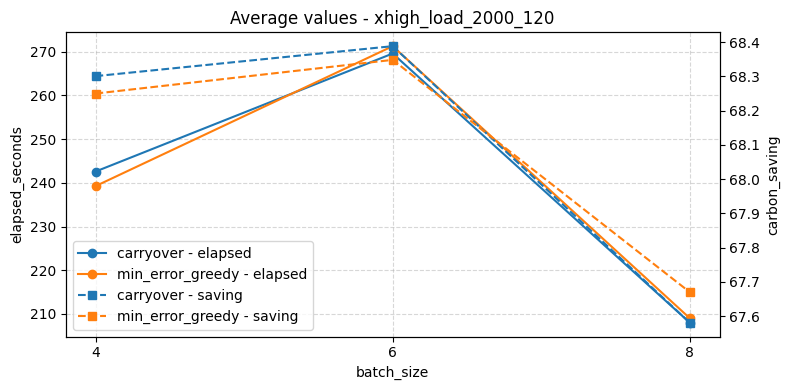

In [ ]:
filtered = plot_df[
    (plot_df["batch_size"].isin([4, 6, 8])) &
    (plot_df["policy"].isin(["min_error_greedy", "carryover"]))
].copy()

summary = (
    filtered.groupby(["scenario_id", "policy", "batch_size"], as_index=False)
    .agg(
        carbon_saving_avg=("carbon_saving", "mean"),
        carbon_saving_min=("carbon_saving", "min"),
        carbon_saving_max=("carbon_saving", "max"),
        elapsed_seconds_avg=("elapsed_seconds", "mean"),
        elapsed_seconds_min=("elapsed_seconds", "min"),
        elapsed_seconds_max=("elapsed_seconds", "max"),
    )
    .sort_values(["scenario_id", "policy", "batch_size"])
    .reset_index(drop=True)
)
pd.set_option("display.max_rows", None)
display(summary)

# Compact plot per scenario: average values for carbon_saving and elapsed_seconds
for scenario_id in sorted(filtered["scenario_id"].unique()):
    s = summary[summary["scenario_id"] == scenario_id]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax2 = ax.twinx()

    for mode, g in s.groupby("policy"):
        ax.plot(g["batch_size"], g["elapsed_seconds_avg"],
                marker="o", linestyle="-", label=f"{mode} - elapsed")
        ax2.plot(g["batch_size"], g["carbon_saving_avg"],
                 marker="s", linestyle="--", label=f"{mode} - saving")

    ax.set(
        title=f"Average values - {scenario_id}",
        xlabel="batch_size",
        ylabel="elapsed_seconds",
        xticks=sorted(s["batch_size"].unique()),
    )
    ax2.set_ylabel("carbon_saving")

    ax.grid(True, linestyle="--", alpha=0.5)

    lines = ax.get_lines() + ax2.get_lines()
    ax.legend(lines, [l.get_label() for l in lines], loc="best")

    fig.tight_layout()
    plt.show()

## Parallelism and rollback

In [25]:
# Let's understand if more parallelism yields less elapsed_time
# Get only carryover and min_error_greedy modes
df_gr_ret = df[~df["policy"].str.contains("offline|online")]
# For each scenario and for each N, we want to know a much elapsed_time is spared with runs having parallelism > 1 compared to runs with parallelism = 1
group_cols = ["scenario_id", "batch_size"]

# Baseline: prendiamo il max elapsed_seconds tra le run con parallelism=1
baseline = (
    df_gr_ret[df_gr_ret["parallelism"] == 1]
    .groupby(group_cols)
    .agg(
        elapsed_parallelism_1=("elapsed_seconds", "max"),
    )
    .reset_index()
)

# Run con parallelism > 1
parallel = (
    df_gr_ret[df_gr_ret["parallelism"] > 1]
    [
        group_cols
        + [
            "parallelism",
            "elapsed_seconds",
            "peak_concurrent_workers",
            "avg_concurrent_workers",
            "policy",
            "RB_max_consecutive",
            "total_RBs",
            "carbon_saving"
        ]
    ]
)

# confronto
comparison = parallel.merge(
    baseline,
    on=group_cols,
    how="inner",
)

comparison["seconds_saved"] = (
    comparison["elapsed_parallelism_1"]
    - comparison["elapsed_seconds"]
)

comparison["speedup_pct"] = (
    comparison["seconds_saved"]
    / comparison["elapsed_parallelism_1"]
    * 100
)

# Set columns ordering for comparison for better readability
comparison = comparison[
    [
        "scenario_id",
        "batch_size",
        "parallelism",
        "elapsed_seconds",
        "elapsed_parallelism_1",
        "seconds_saved",
        "speedup_pct",
        "carbon_saving",
        "peak_concurrent_workers",
        "avg_concurrent_workers",
        "policy",
        "RB_max_consecutive",
        "total_RBs",
    ]
] 

display(comparison.head())
# comparison
# display for scenario xxhigh_load_2081
# display(comparison[(comparison["scenario_id"] == "xxhigh_load_2081") & (comparison["batch_size"] == 16)])
# display(comparison[(comparison["scenario_id"] == "high_load_105") & (comparison["batch_size"] == 16)])
# display(comparison[(comparison["scenario_id"] == "low_load_2028") & (comparison["batch_size"] == 16)])


summary = (
    comparison
    .groupby("parallelism")
    .agg(
        runs=("scenario_id", "count"),
        avg_saved_seconds=("seconds_saved", "mean"),
        median_saved_seconds=("seconds_saved", "median"),
        avg_speedup_pct=("speedup_pct", "mean"),
        median_speedup_pct=("speedup_pct", "median"),
        avg_peak_workers=("peak_concurrent_workers", "mean"),
        avg_workers=("avg_concurrent_workers", "mean"),
        avg_rollbacks=("total_RBs", "mean"),
    )
)

summary

,scenario_id,batch_size,parallelism,elapsed_seconds,elapsed_parallelism_1,seconds_saved,speedup_pct,carbon_saving,peak_concurrent_workers,avg_concurrent_workers,policy,RB_max_consecutive,total_RBs
0,high_load_1500_92,1,8,458.72,709.98,251.26,35.389729,67.37,8,5.81,min_error_greedy,0,0
1,high_load_1500_92,4,8,108.75,239.44,130.69,54.581524,68.31,8,6.47,min_error_greedy,0,0
2,high_load_1500_92,6,8,136.85,570.99,434.14,76.032855,68.50,8,7.29,min_error_greedy,0,0
3,high_load_1500_92,8,8,102.98,426.26,323.28,75.841036,67.65,8,7.49,min_error_greedy,0,0
4,high_load_1500_92,22,8,361.82,1184.11,822.29,69.443717,65.14,8,7.56,min_error_greedy,0,0


,runs,avg_saved_seconds,median_saved_seconds,avg_speedup_pct,median_speedup_pct,avg_peak_workers,avg_workers,avg_rollbacks
parallelism,,,,,,,,
8,100,454.4092,393.515,58.316248,67.833715,8.0,6.8920,194.68
14,20,462.5520,386.270,59.097333,67.341951,14.0,10.0160,0.00
20,100,451.9849,379.660,57.296773,67.276705,20.0,11.3463,351.57


### Parallelism is useful
Parallelism yields a significant reduction in elapsed_time. Speedup peaks at 75% for N=6|8, and yields a 54% reduction for N=4. The speedup is less pronounced for N=1, but still yields a 35% reduction in elapsed_time.

`avg_workers` stays at 11 even for `parallelism=20` probably due to my **hardware capabilities**, despite having set a higher number of thread dedicated to WSL.

## Rollback evaluation

,batch_size,parallelism,policy,carbon_saving,elapsed_seconds,total_RBs
219,8,1,min_error_greedy,70.15,577.20,0
224,8,1,carryover,70.12,531.29,0
223,6,1,carryover,69.96,656.50,0
218,6,1,min_error_greedy,69.85,697.41,0
217,4,1,min_error_greedy,69.65,370.95,0


,group,runs,avg_carbon_saving,avg_elapsed_seconds,min_carbon_saving,max_carbon_saving
0,with_rollbacks,44,67.025227,482.965,63.19,68.60
1,without_rollbacks,100,66.290500,412.518,55.79,70.15


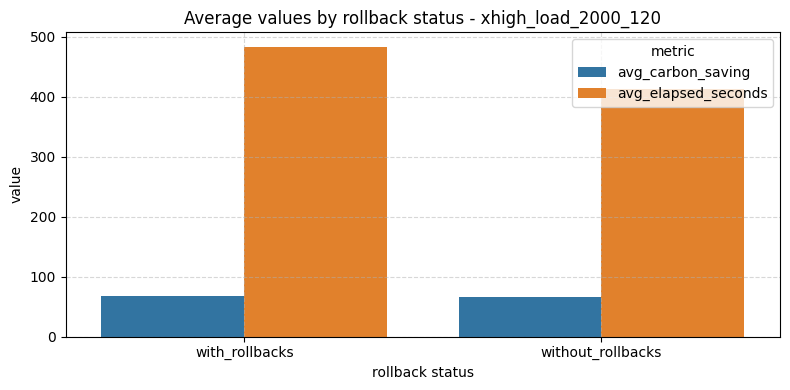

In [26]:
'''
Get the top 5 runs for carbon saving for one scenario. Check how many of them have total_RBs > 0.
Then get the runs with total_RBs > 0 and measure the average carbon saving and elapsed_time for them.
Compare with the average carbon saving and elapsed_time for runs with no rollbacks.
'''

# Pick one scenario to analyze
# scenario = "high_load_1500_92"
scenario = "xhigh_load_2000_120"

scenario_df = df[df["scenario_id"] == scenario].copy()

# Keep only meaningful columns for the analysis
cols = [
    "scenario_id",
    "batch_size",
    "parallelism",
    "policy",
    "carbon_saving",
    "elapsed_seconds",
    "total_RBs",
    "RB_max_consecutive",
    "final_global_error",
]
scenario_df = scenario_df[cols].copy()

# Top 5 runs by carbon saving
top5 = scenario_df.nlargest(5, "carbon_saving").copy()
# For better readability, display the exact top 5 rows
print(f"Top 5 runs for {scenario} by carbon_saving:")
display(top5[["batch_size", "parallelism", "policy", "carbon_saving", "elapsed_seconds", "total_RBs"]])

# Check how many of the top 5 have total_RBs > 0
num_with_rollbacks = int((top5["total_RBs"] > 0).sum())
print(f"Top 5 runs with total_RBs > 0: {num_with_rollbacks} / 5")

# Compare averages for runs with and without rollbacks
with_rollbacks = scenario_df[scenario_df["total_RBs"] > 0].copy()
without_rollbacks = scenario_df[scenario_df["total_RBs"] == 0].copy()

summary = {
    "group": ["with_rollbacks", "without_rollbacks"],
    "runs": [
        len(with_rollbacks),
        len(without_rollbacks),
    ],
    "avg_carbon_saving": [
        with_rollbacks["carbon_saving"].mean() if len(with_rollbacks) else None,
        without_rollbacks["carbon_saving"].mean() if len(without_rollbacks) else None,
    ],
    "avg_elapsed_seconds": [
        with_rollbacks["elapsed_seconds"].mean() if len(with_rollbacks) else None,
        without_rollbacks["elapsed_seconds"].mean() if len(without_rollbacks) else None,
    ],
    "min_carbon_saving": [
        with_rollbacks["carbon_saving"].min() if len(with_rollbacks) else None,
        without_rollbacks["carbon_saving"].min() if len(without_rollbacks) else None,
    ],
    "max_carbon_saving": [
        with_rollbacks["carbon_saving"].max() if len(with_rollbacks) else None,
        without_rollbacks["carbon_saving"].max() if len(without_rollbacks) else None,
    ],
}

summary_df = pd.DataFrame(summary)
display(summary_df)

# Optional plot: compare mean carbon_saving and elapsed_seconds for groups
summary_plot = summary_df[["group", "avg_carbon_saving", "avg_elapsed_seconds"]].copy()
summary_plot = summary_plot.melt(
    id_vars="group",
    value_vars=["avg_carbon_saving", "avg_elapsed_seconds"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(8, 4))
sns.barplot(data=summary_plot, x="group", y="value", hue="metric")
plt.title(f"Average values by rollback status - {scenario}")
plt.ylabel("value")
plt.xlabel("rollback status")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Rollback not so useful
Rollbacks ensure a higher minimum carbon saving (63% vs 56%), but the average carbon saving is almost the same (75% vs 80%). The elapsed_time instead is higher, 1.16x times slower for runs with rollbacks than for runs without rollbacks (482s vs 412s for high_load_1900_92).

Rollbacks can probably be avoided.



## Planet vs Profit
`test2` marked tests have the error threshold varying in `(3.0,3.5,4.0,4.5)` to observe how much the error threshold affects the carbon saving. The results show that the error threshold has a significant impact on the carbon saving, with higher thresholds yielding lower carbon savings.

In fact, the intuition is that simply relying on time shifting does not yield much carbon saving (if any), and that the main source of carbon saving is exploiting the error threshold.

,policy,error_threshold_bin,avg_carbon_saving
0,carryover,3.0,51.396000
1,offline_ant_colony,3.0,54.640000
2,offline_bandit,3.0,45.210000
3,offline_greedy_cheapest,3.0,54.810000
4,online_ant_colony,3.0,38.340000
5,online_bandit,3.0,41.453333
6,online_greedy_singleton,3.0,42.830000
7,carryover,3.5,59.356000
8,offline_ant_colony,3.5,61.750000
9,offline_bandit,3.5,51.720000


policy,carryover,offline_ant_colony,offline_bandit,offline_greedy_cheapest,online_ant_colony,online_bandit,online_greedy_singleton
error_threshold_bin,,,,,,,
3.0,51.396,54.64,45.21,54.81,38.340000,41.453333,42.83
3.5,59.356,61.75,51.72,61.74,50.070000,49.133333,53.42
4.0,67.528,69.94,62.24,68.55,61.364444,60.494444,66.35
4.5,75.394,77.04,69.68,75.61,71.123333,68.850000,75.39


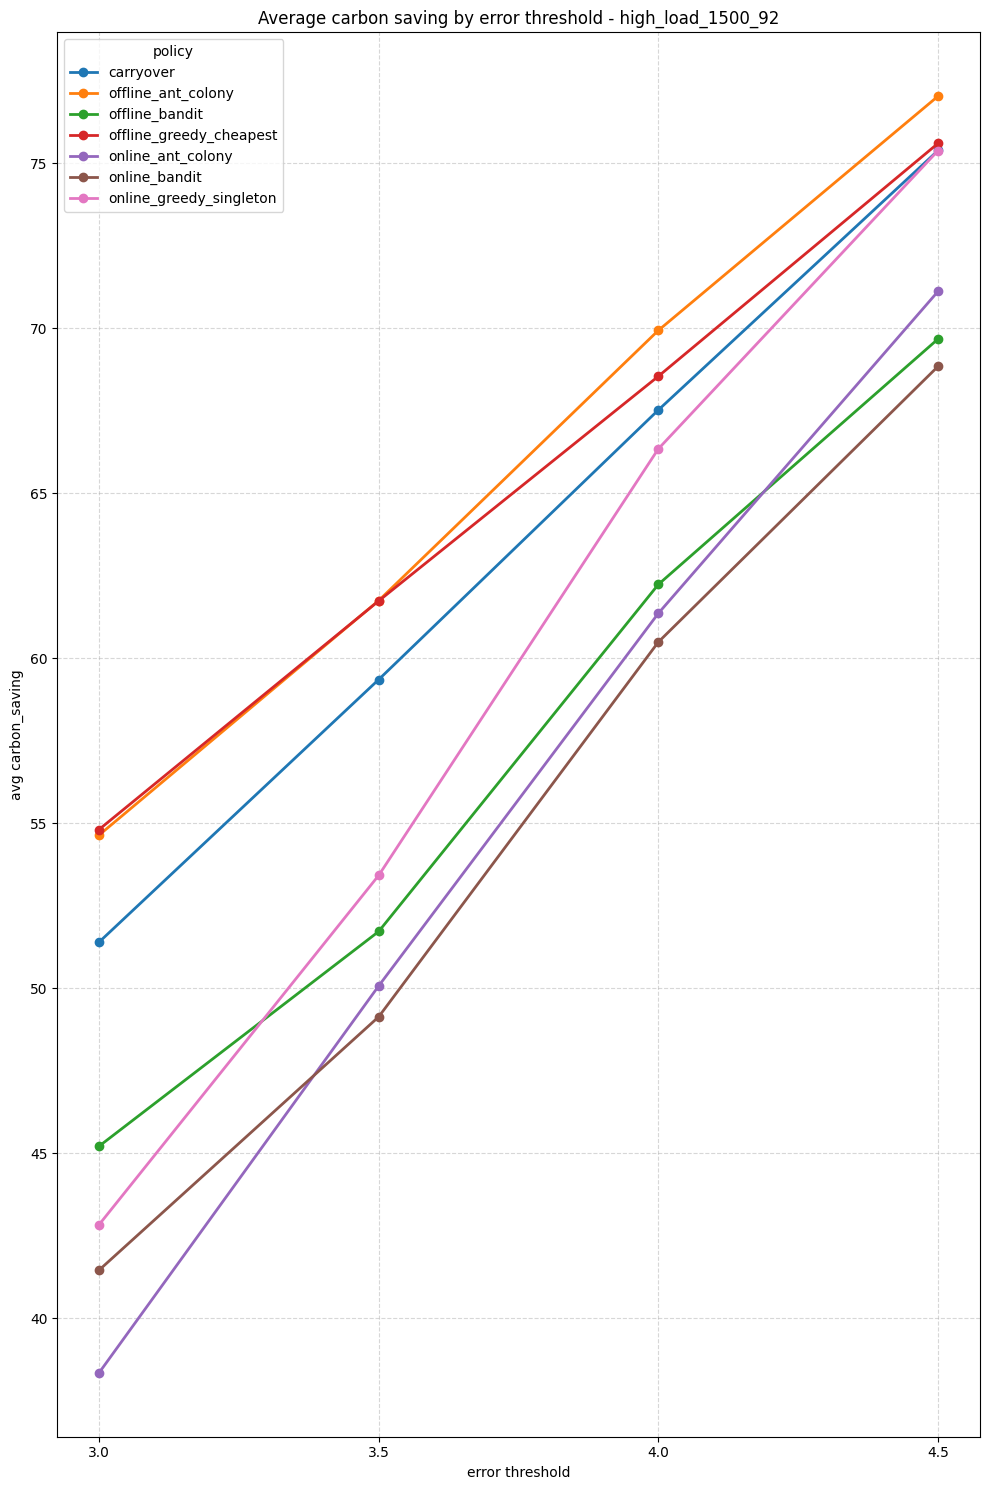

In [27]:
'''
Display average carbon saving for each policy for each error threshold for a selected scenario.
Consider that final_global_error should be close to the error threshold used, but may differ of a few percents (e.g. if the threshold is 4.0, final_global_err may be 3.98).
It would be wise to use binning, knowing that the error threshold is in (3.0, 3.5, 4.0, 4.5).
'''

df_2 = df_all[df_all["path"].str.contains("cfg_test2")].copy()

# Pick a scenario to analyze
scenario = "high_load_1500_92"
# scenario = "xhigh_load_2000_120"

scenario_df = df_2[df_2["scenario_id"] == scenario].copy()
scenario_df["final_global_error"] = pd.to_numeric(scenario_df["final_global_error"], errors="coerce")
scenario_df = scenario_df.dropna(subset=["final_global_error", "carbon_saving", "policy"]).copy()

# Error thresholds used in the experiment
thresholds = [3.0, 3.5, 4.0, 4.5]
# Use a small bin around each threshold to account for small numerical differences
bins = [2.75, 3.25, 3.75, 4.25, 4.75]
labels = [3.0, 3.5, 4.0, 4.5]

scenario_df["error_threshold_bin"] = pd.cut(
    scenario_df["final_global_error"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False,
)

summary = (
    scenario_df
    .dropna(subset=["error_threshold_bin"])
    .groupby(["policy", "error_threshold_bin"], as_index=False)["carbon_saving"]
    .mean()
    .rename(columns={"carbon_saving": "avg_carbon_saving"})
    .sort_values(["error_threshold_bin", "policy"])
    .reset_index(drop=True)
)

display(summary)

# Pivot table for easier comparison
pivot = (
    summary
    .pivot(index="error_threshold_bin", columns="policy", values="avg_carbon_saving")
    .reindex(labels)
)
display(pivot)

# Plot: average carbon saving by error threshold, one line per infeasibility mode
plt.figure(figsize=(10, 15))
for mode in pivot.columns:
    plt.plot(pivot.index.astype(float), pivot[mode].values, marker="o", linewidth=2, label=mode)

plt.title(f"Average carbon saving by error threshold - {scenario}")
plt.xlabel("error threshold")
plt.ylabel("avg carbon_saving")
plt.xticks(thresholds)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="policy")
plt.tight_layout()
plt.show()

## Relying only on shifting

So, to prove the intuition mentioned above, let's limit the **flavours** to only the most accurate one, making the time shift the only possible source of carbon saving.


What is expected is that if the sinusoidal load is in phase with the carbon intensity, then the carbon saving should be significant, while if it is opposed in phase, then the carbon saving should be negligible.

`test3` have phase opposition, `test4` are in phase, `test5` have phase 25% disalignment (50% disalignment would be phase inversion).



### Observation on the cap levels
Setting the cap level properly is important, as it can significantly affect the carbon saving. 

Considering that for the scenario `high_load_1500_92` the average requests incoming per slot is 1500 but may reach peaks up to 3000, setting the highest cap (the one triggering strong rebound effect), below 3000, will lead the scheduler to work in a regime where the rebound effect is easily triggered and must distribute requests more equally across the slots, losing the opportunity to exploit the carbon intensity variations across the slots, but at the same time to limit the severity of the rebound effect which may be easily triggered.


### Observation on the last slot
Requests tend to accumulate in the last slot, since upon reaching the last slot, the scheduler has no other choice but to schedule all remaining requests in that slot. It happens similarly also for the last few slots, but the effect is more pronounced for the last slot. 
Especially when the last slot has a low carbon intensity, the scheduler might tend to schedule more requests there despite the rebound effect.


We could choose, for testing purposes, to let the scheduler schedule requests in slots beyond the last slot and leave them out of the evaluation. This would better mimick a real-world scenario where there is no "last slot" and then a window is evaluated, however this would lead to have, at each test execution, a slightly different amount of requests to be evaluated overall.

#### test3 - phase opposition
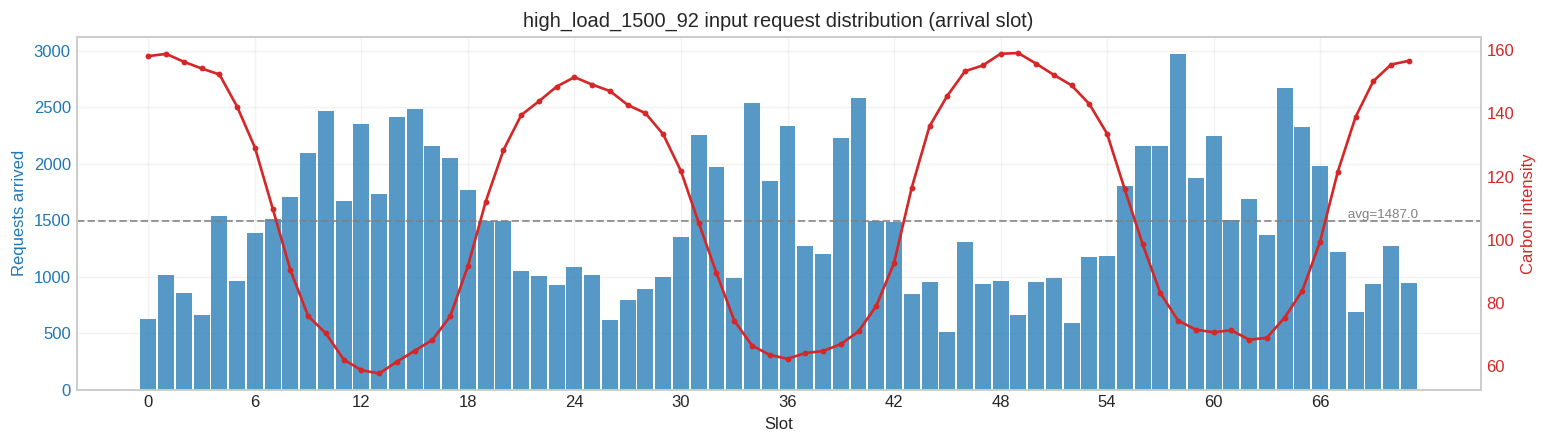
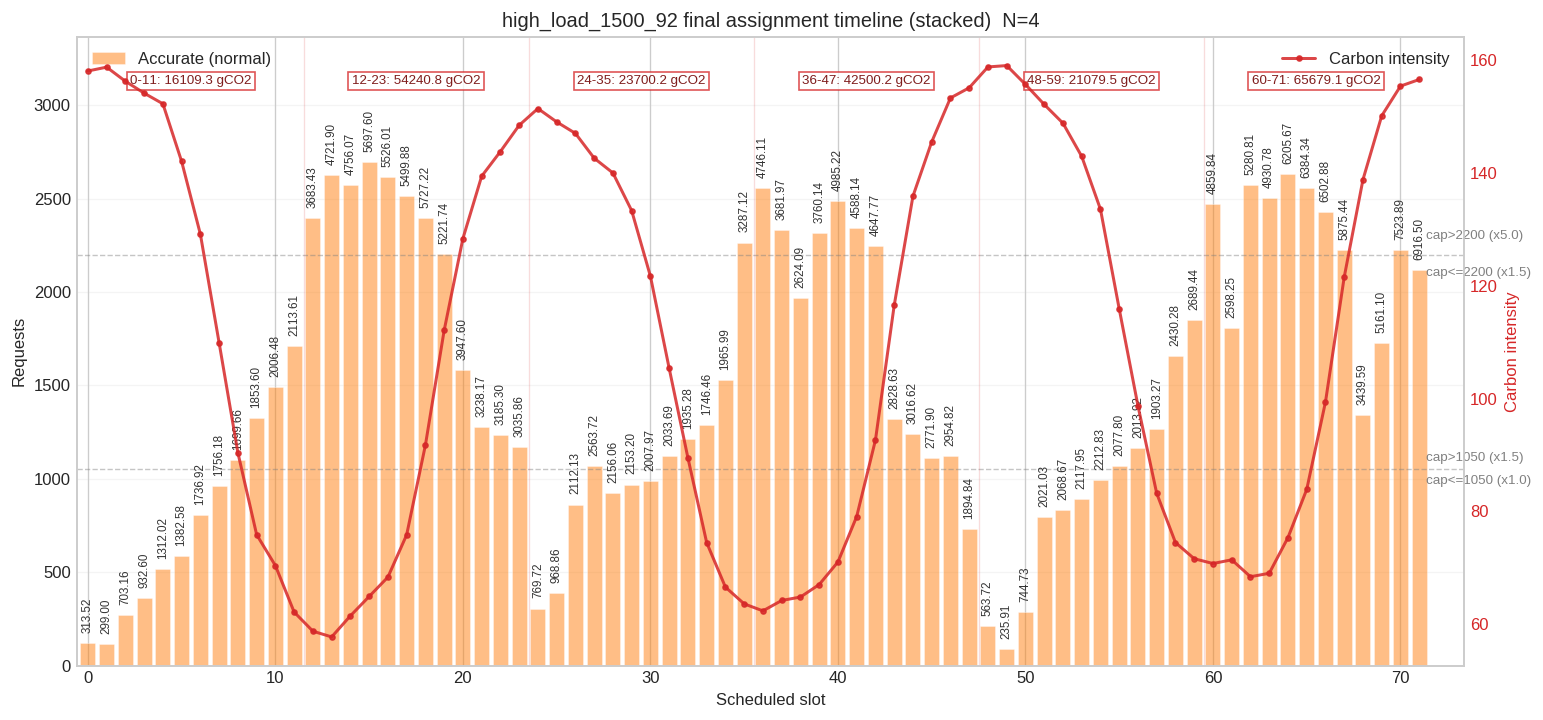

#### test4 - in phase
Below are images displaying different combinations of cap levels for the scenarios high_load_1500_92 and xhigh_load_2000_120.
These images help visualize how different capacity levels impact the outcome.
<!-- 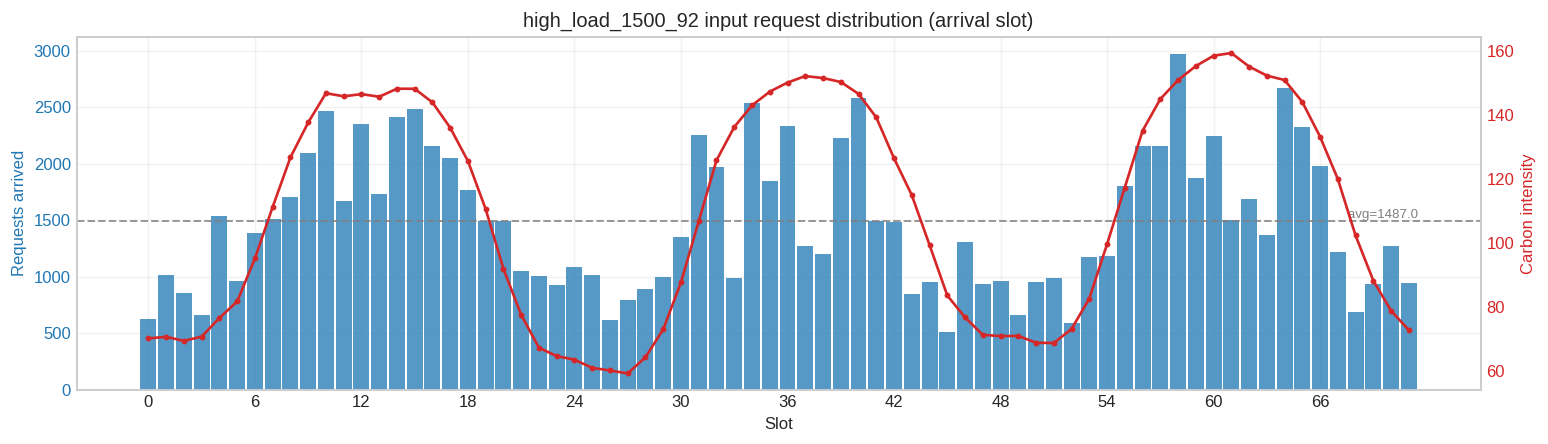 -->
<!-- 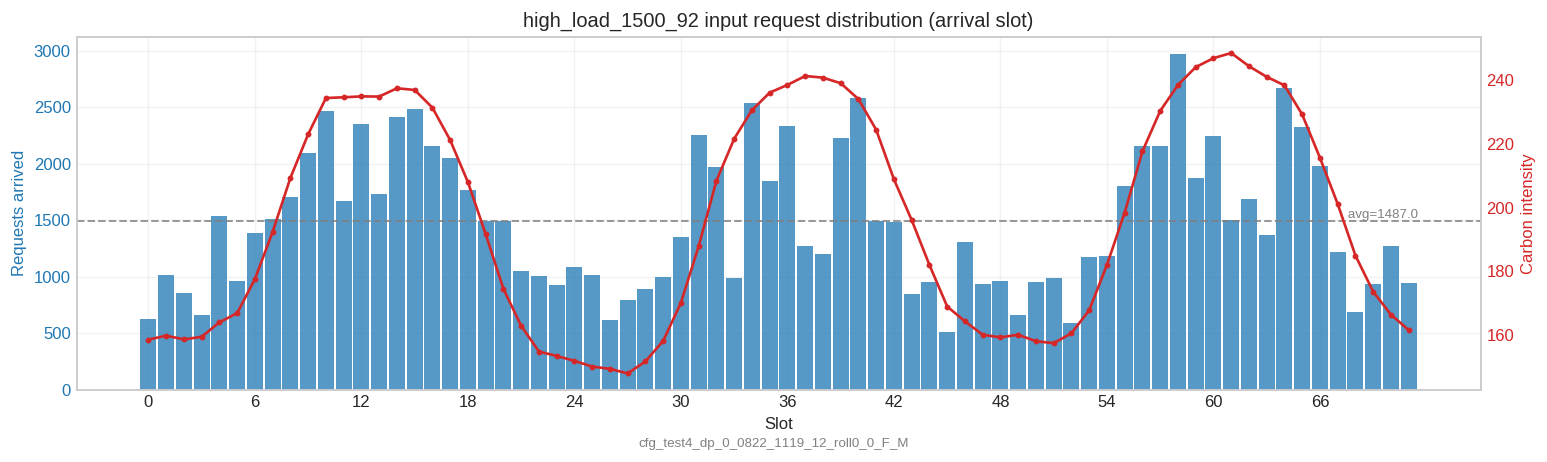 -->
##### Scenario high_load_1500_92
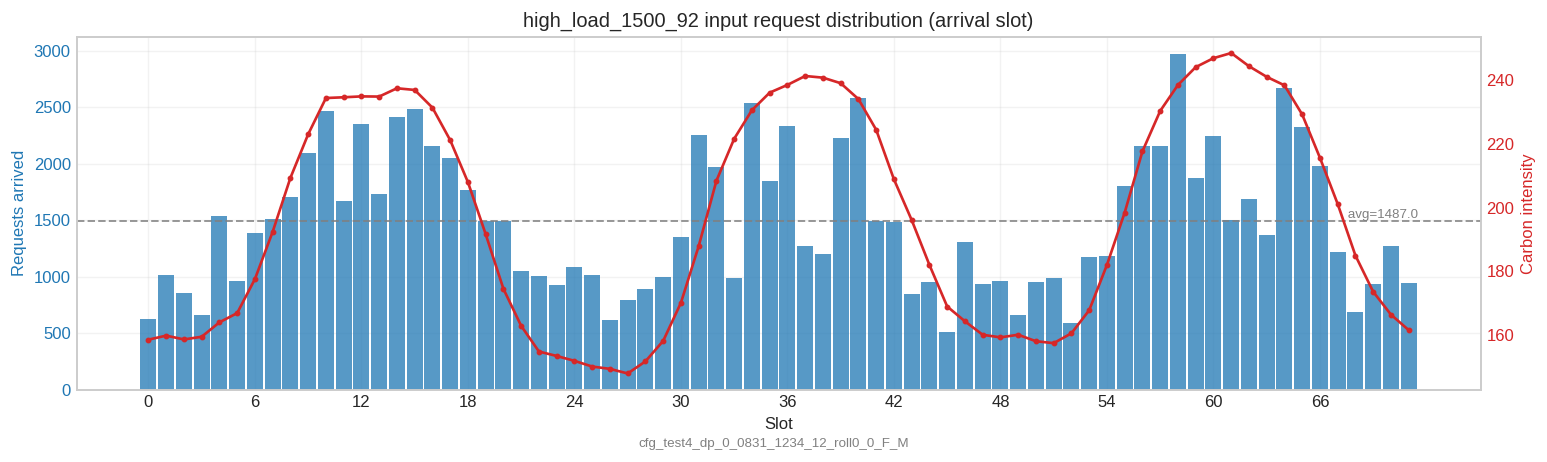
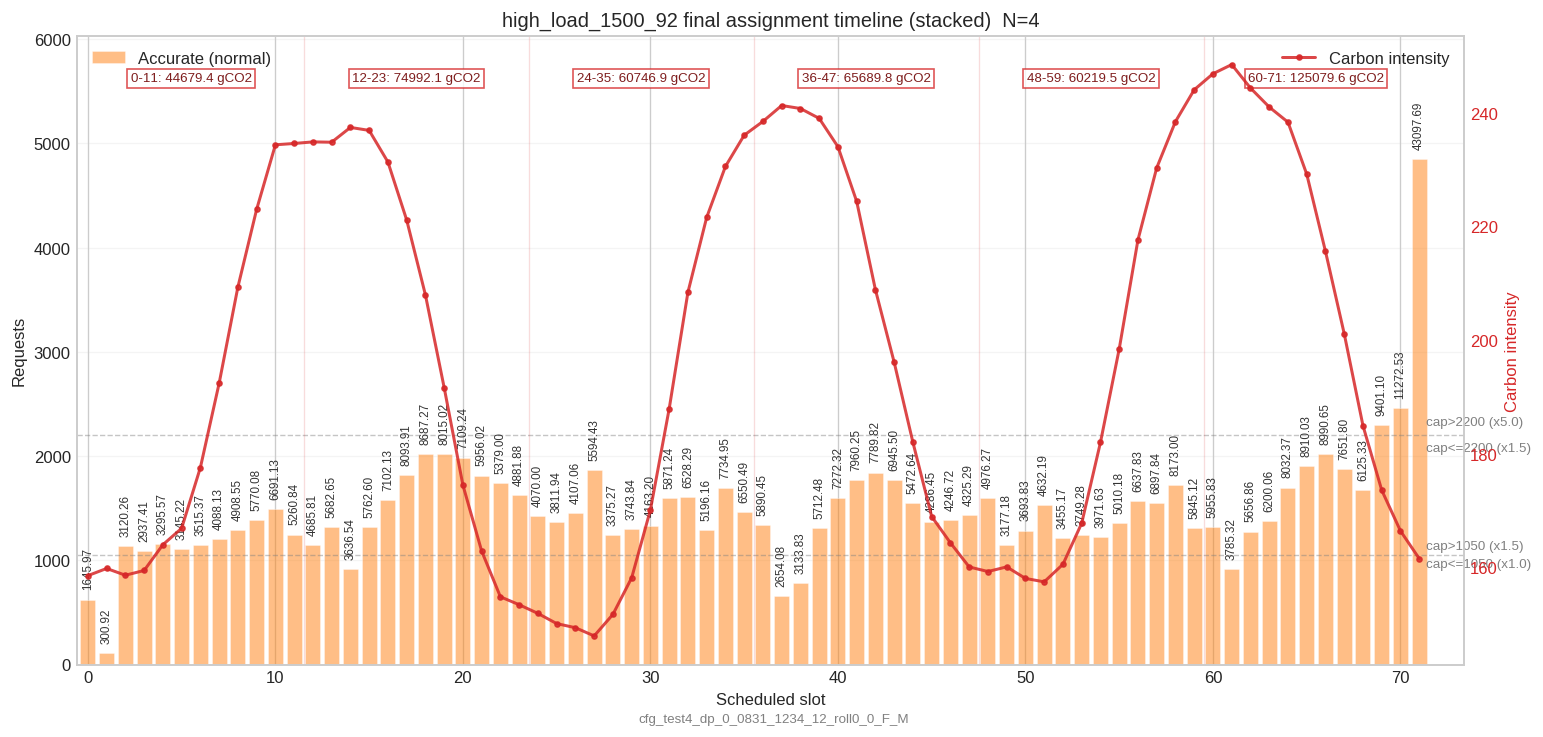
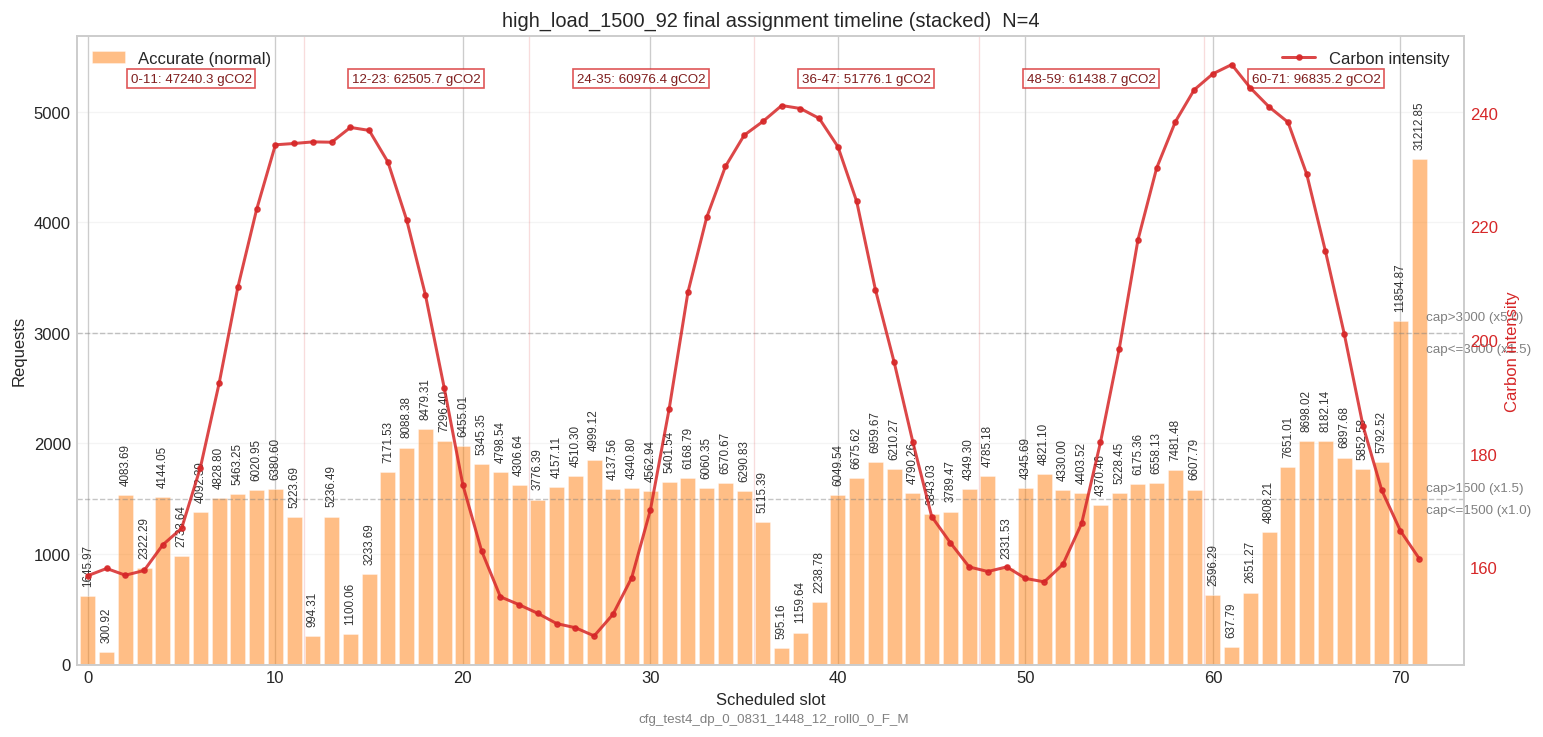
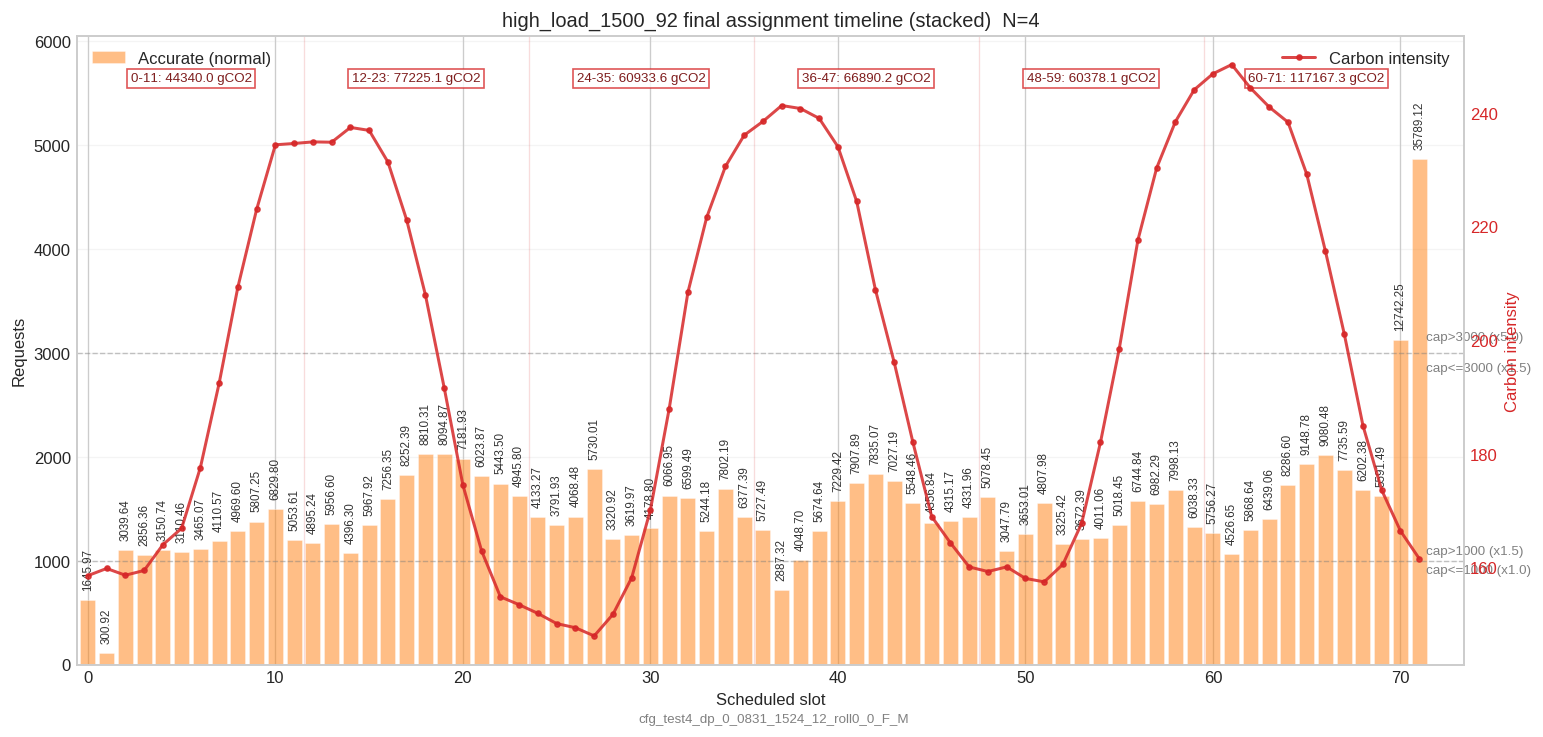
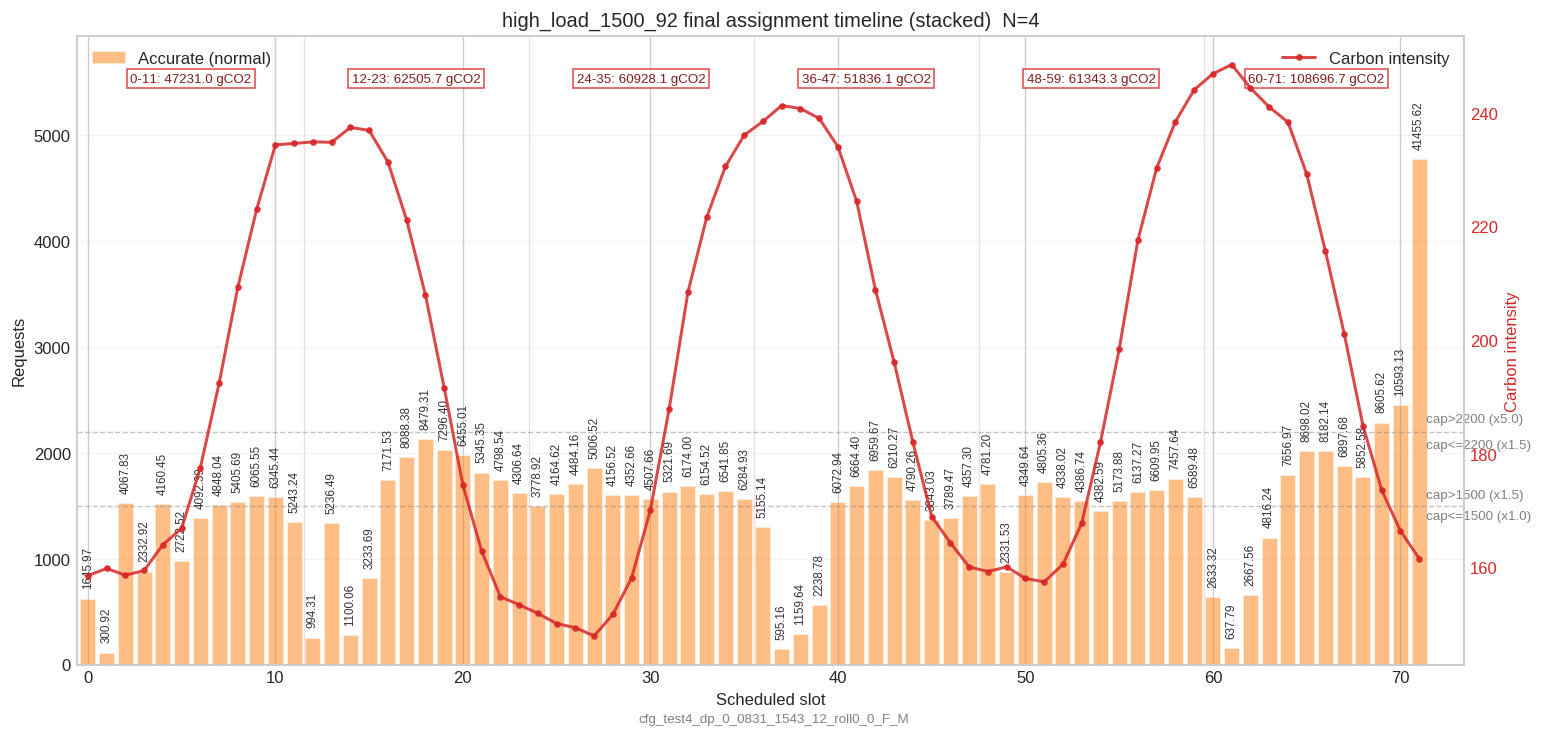

<!-- 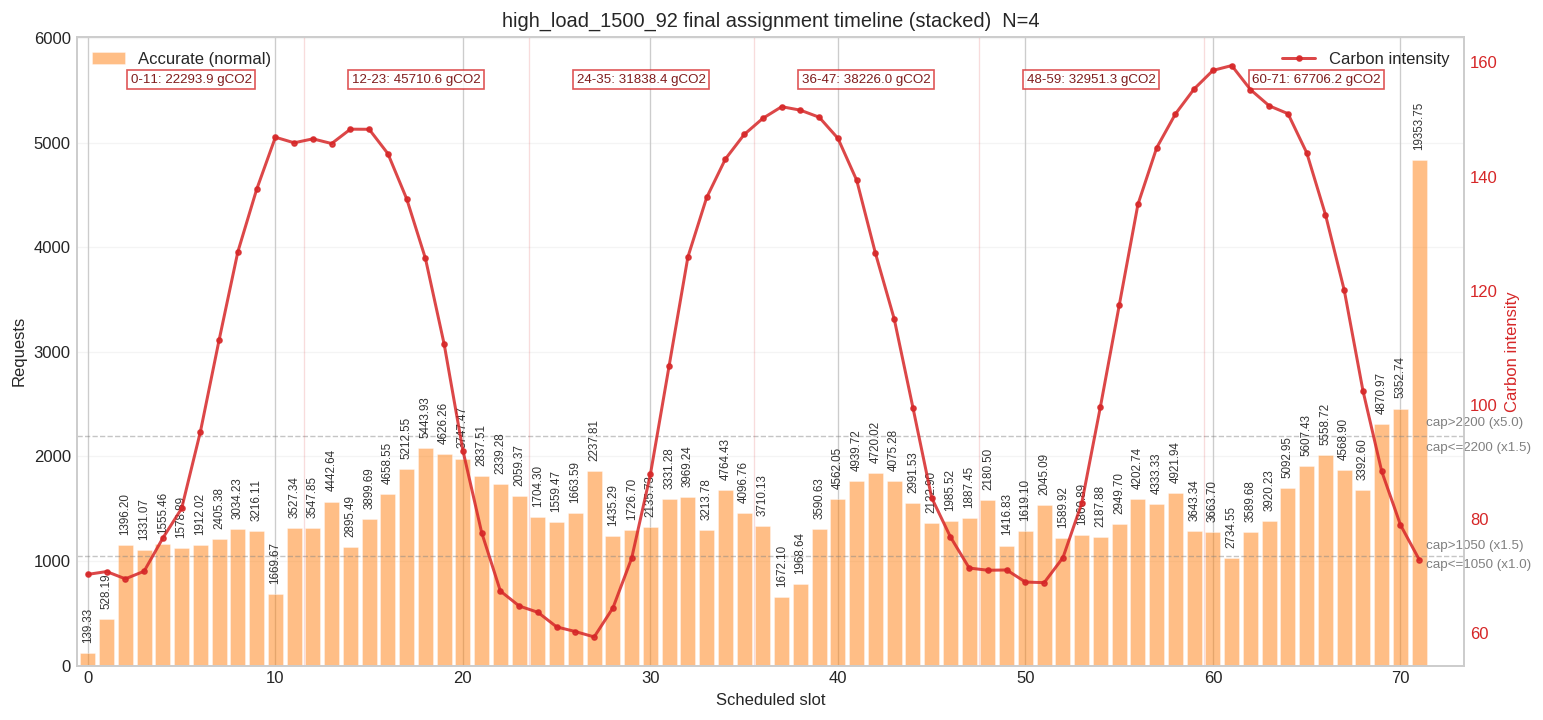 -->
<!-- 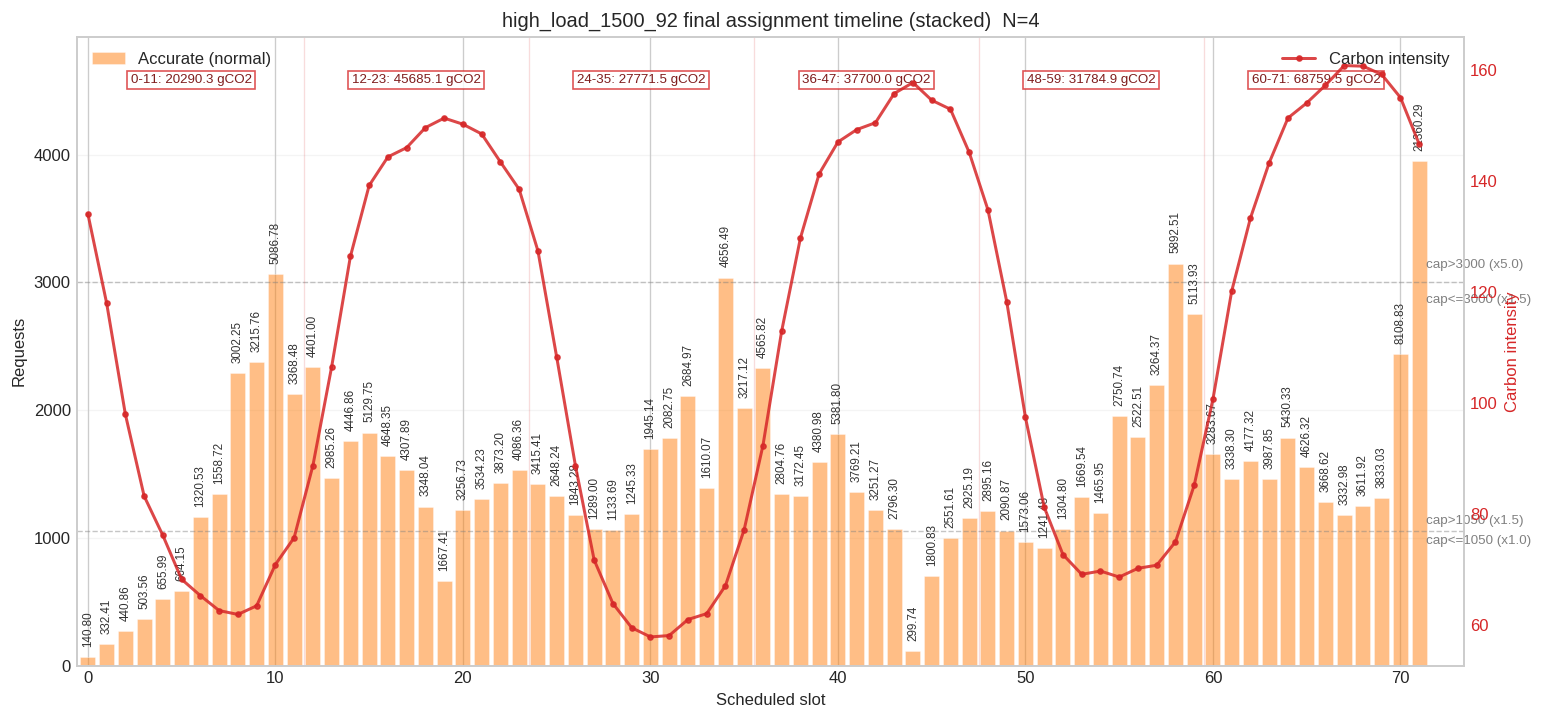 -->
##### Scenario xhigh_load_2000_120
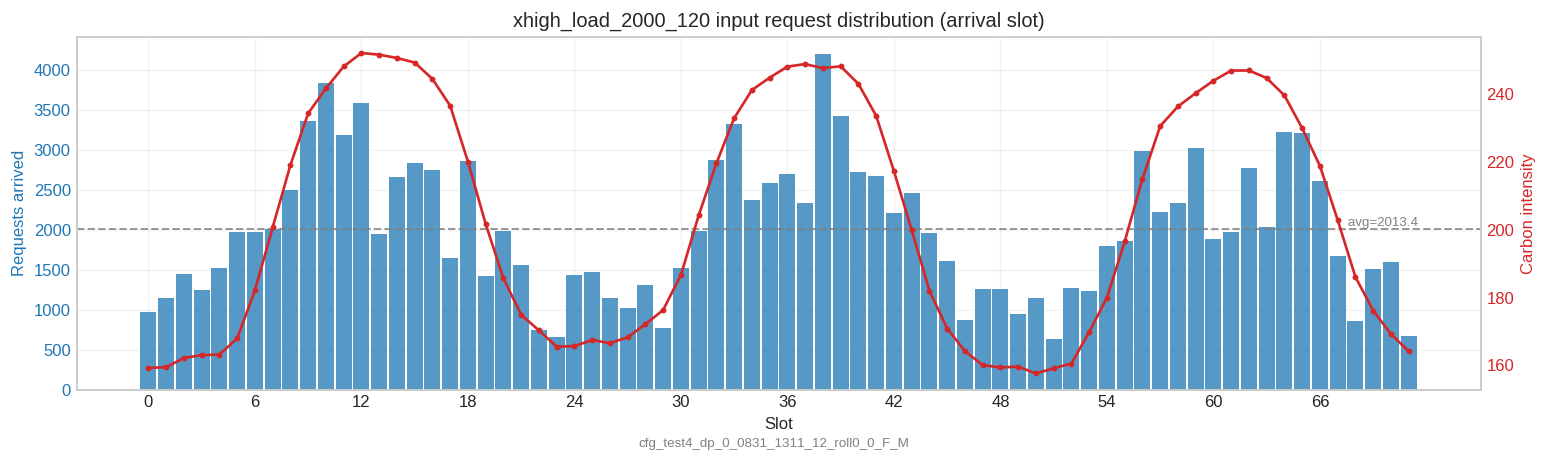
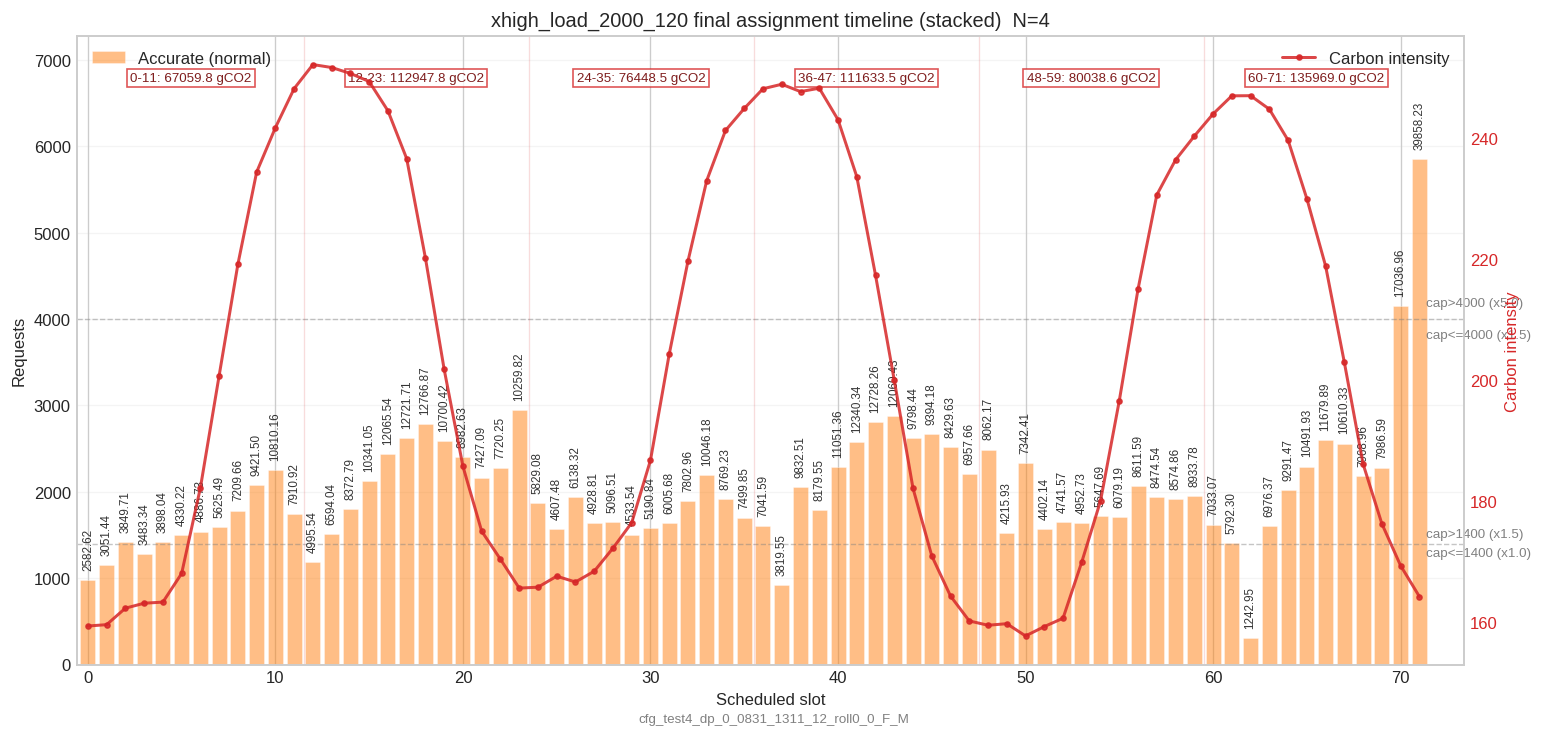
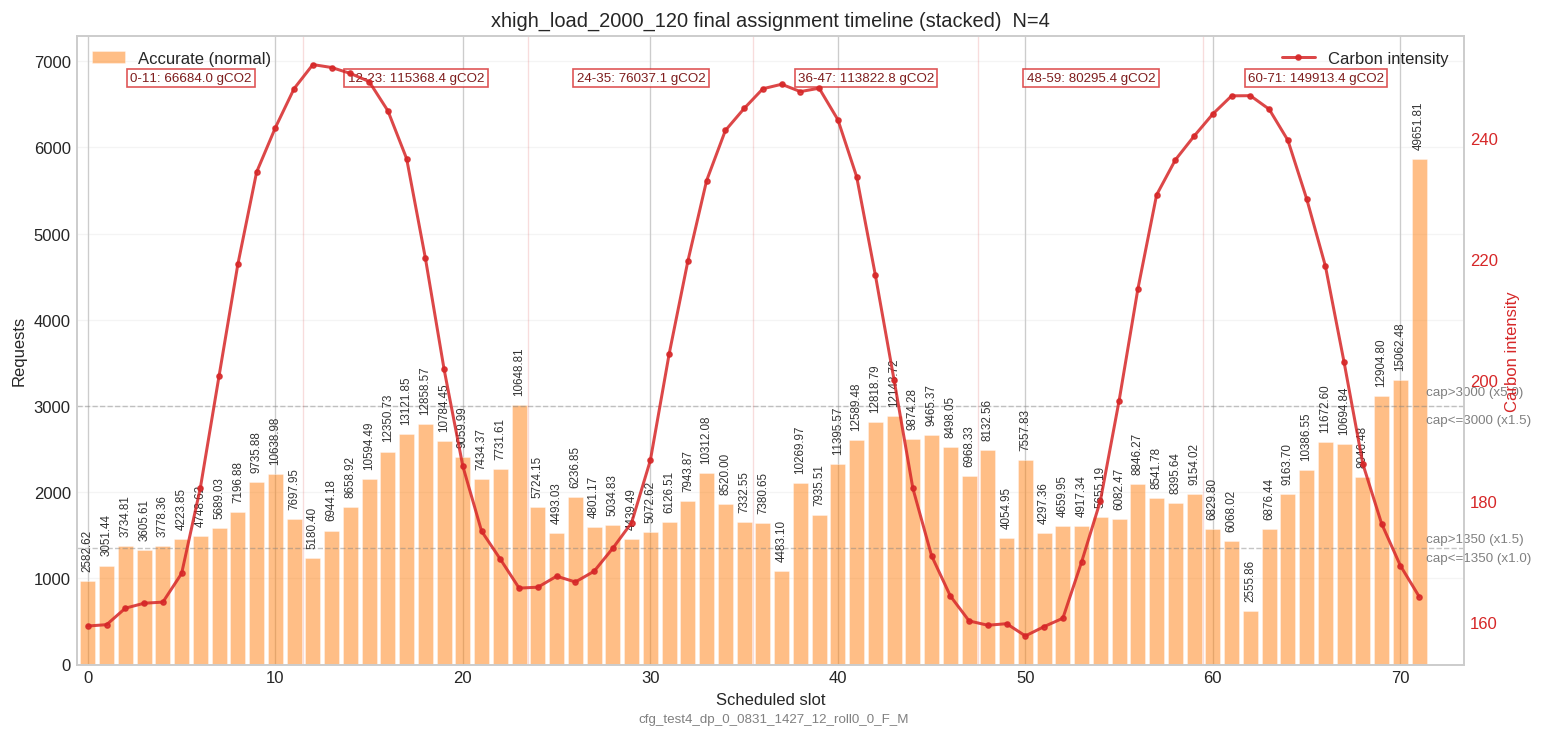
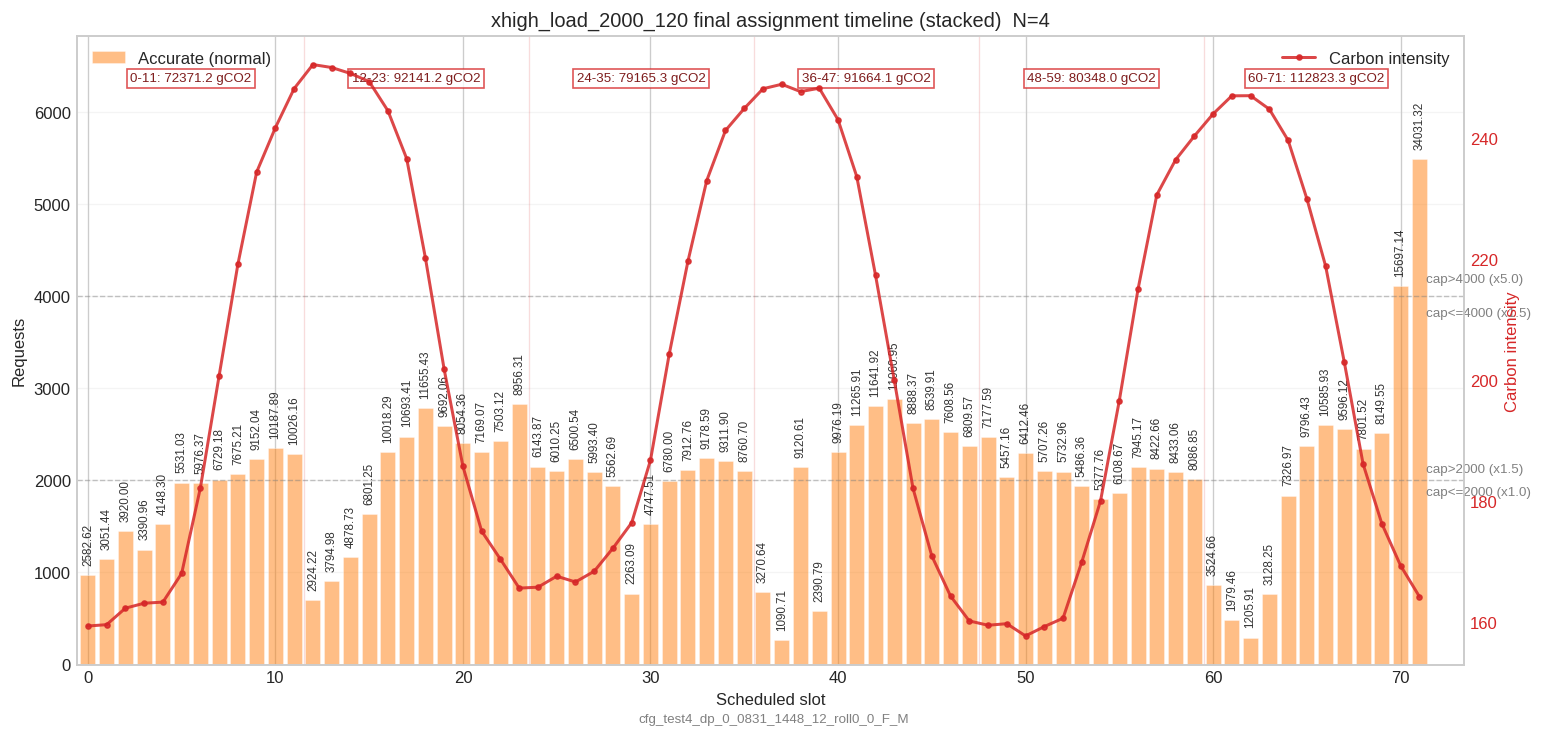
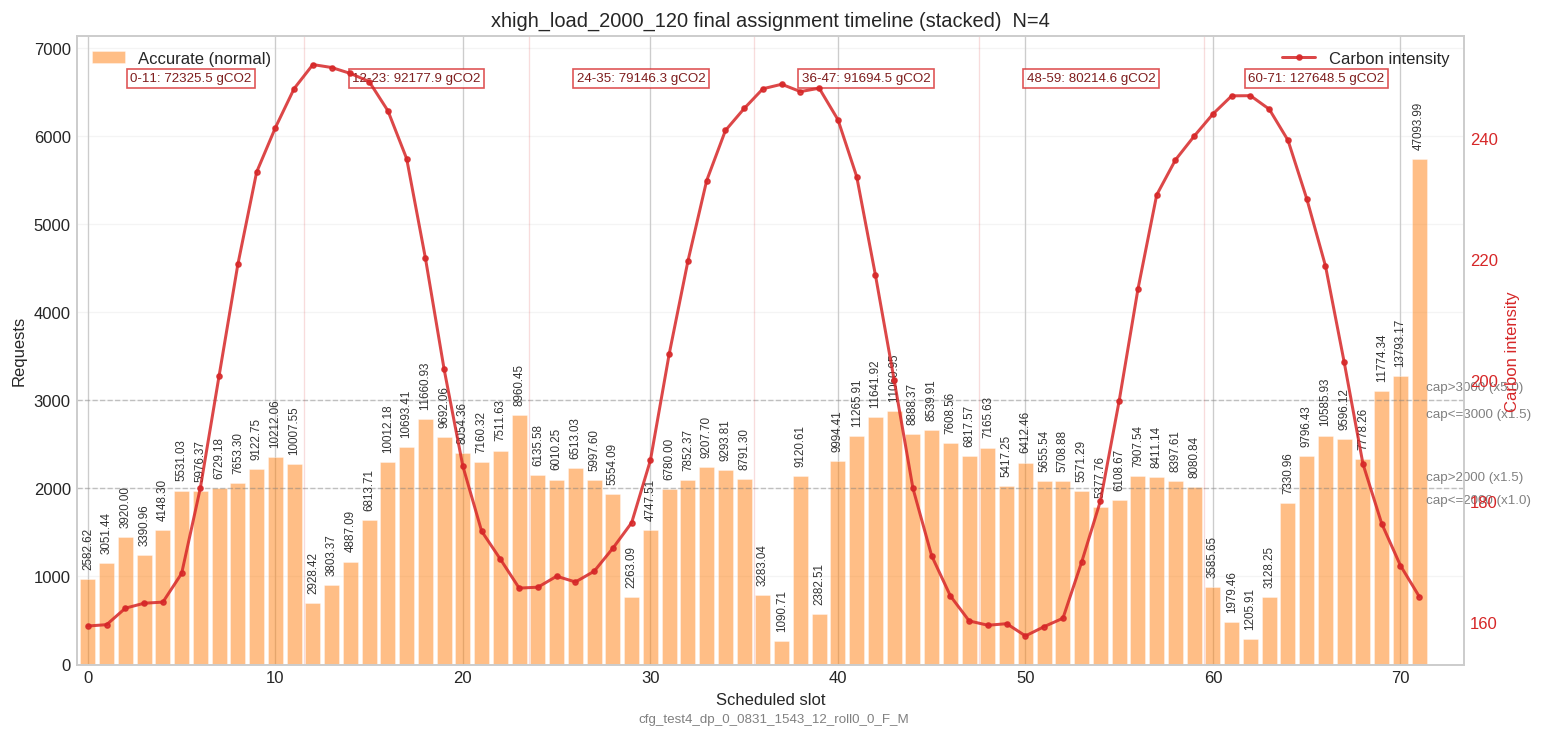

##### Summary
| Scenario | CAP levels | Carbon Saving |
|----------|------------|----------------|
| high_load_1500_92 | (1050,2200) | 10.77 |
| high_load_1500_92 | (1500,3000) | 6.2 |
| high_load_1500_92 | (1000,3000) | 3.67 |
| high_load_1500_92 | **(1500,2200)** | **12.91** |
| xhigh_load_2000_120 | (1400,4000) | 6.29 |
| xhigh_load_2000_120 | (1350,3000) | 12.47 |
| xhigh_load_2000_120 | (2000,4000) | 8.12 |
| xhigh_load_2000_120 | **(2000,3000)** | **14.46** |


Note that for the two scenario, input requests range from 500 to 3000 and 4000 respectively.

Shifting provides best saving results when the gap between two cap levels is narrower,the first matching the average input request rate and the second being below the peaks.
Setting the second cap level higher makes shifting less effective in achieving carbon savings since it (almost) never happens that the input requests exceed this higher cap level, lowering the baseline cost .\
Setting it lower instead, aside from increasing the baseline cost, forces carbonshift to optimize shifting more aggressively to stay within the cap.\
Having the first cap level below the average input request reduces room for shifting, as in most slots the requests will exceed this cap.\



#### test5 - 25% disalignment
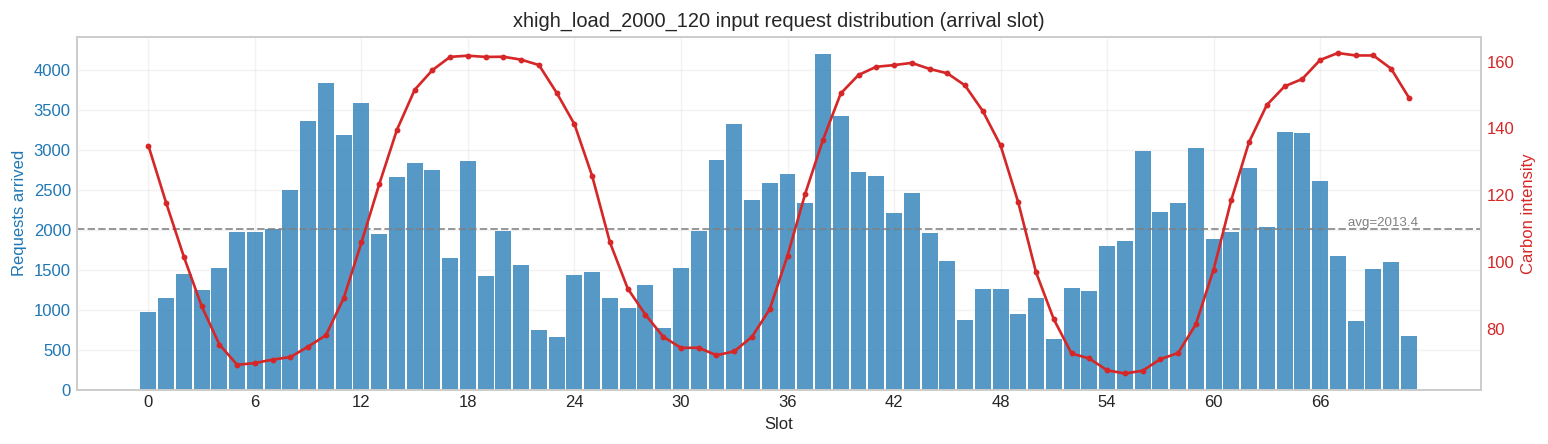



In [28]:
# df_shift = df_all[df_all["path"].str.contains("cfg_test3") |
#      df_all["path"].str.contains("cfg_test4") |
#      df_all["path"].str.contains("cfg_test5") |
#      df_all["path"].str.contains("cfg_test6")].copy()


# df_test3 = df_all[df_all["path"].str.contains("cfg_test3")].copy()
# df_test4 = df_all[df_all["path"].str.contains("cfg_test4")].copy()
# df_test5 = df_all[df_all["path"].str.contains("cfg_test5")].copy()
# df_test6 = df_all[df_all["path"].str.contains("cfg_test6")].copy()

# display(df_test3.head())
# display(df_test4.head())
# display(df_test5.head())
# display(df_test6.head())




## Evaluating different cap levels in complete test suite

Let's see how the different cap levels affect the results across the complete test suite.

### Considerations
| test | cap levels scenario 1500 | cap levels scenario 2000 | flavours |
|------|----------------|----------------|----------|
| 8    | 1500/3000  | 2000/4000  | Accurate |
| 9    | 1500/3000  | 2000/4000  | All      |
| 10   | 1000/3000  | 1350/4000  | All      |
| 11   | 1500/2200  | 2000/3000  | Accurate |
| 12   | 1500/2200  | 2000/3000  | All      |


We will now analyze the impact of different cap levels on the results for each test in the complete test suite.
Tables will be provided grouping on the **infeasibility mode**.

In [29]:
# 8 and 9 have cap levels set at 1500/3000 and 2000/4000
# 8 has only Accurate flavour
df_test8 = df_all[df_all["path"].str.contains("cfg_test8")].copy()
# 9 has all flavours
df_test9 = df_all[df_all["path"].str.contains("cfg_test9")].copy()
# 10 has cap levels set at 1000/3000 and 1350/4000
df_test10 = df_all[df_all["path"].str.contains("cfg_test10")].copy()
# 11 has cap levels set at 1500/2200 and 2000/3000 and only accurate flavour
df_test11 = df_all[df_all["path"].str.contains("cfg_test11")].copy()
# 12 has cap levels set at 1500/2200 and 2000/3000
df_test12 = df_all[df_all["path"].str.contains("cfg_test12")].copy()

# 13 has cap level at 2000/4000
df_test13 = df_all[df_all["path"].str.contains("cfg_test13")].copy()
# 14 has cap level at 2000/3000
df_test14 = df_all[df_all["path"].str.contains("cfg_test14")].copy()

# build df_tests adding a column "testID"
df_test8["testID"] = "cfg_test08"
df_test9["testID"] = "cfg_test09"
df_test10["testID"] = "cfg_test10"
df_test11["testID"] = "cfg_test11"
df_test12["testID"] = "cfg_test12"
df_test13["testID"] = "cfg_test13"
df_test14["testID"] = "cfg_test14"

# Exclude test13 and 14 for now, since they only have scenario xhigh_2000
df_tests = pd.concat([df_test8, df_test9, df_test10, df_test11, df_test12], ignore_index=True)


# filter df_tests to include only runs where infeasibility mode is "carryover"
df_tests_carryover = df_tests[df_tests["policy"] == "carryover"].copy()
# display the first few rows of the filtered dataframe 
df_tests_carryover.head()
 
'''
Filter to get only batch size == 4 for carryover
We want a proper summary. For each testID, each infeasibility mode, and each scenario (it's two of them), we want to get average/stddev carbon cost, average/stddev carbon saving, average/min/max elapsed_seconds
'''
df_tests_all_and_batch4 = df_tests[(df_tests["batch_size"] == 4) | (df_tests["policy"] != "carryover")].copy()
# sort by testID, policy, and scenario_id
df_tests_all_and_batch4.sort_values(by=["testID", "policy", "scenario_id"], inplace=True)

df_tests_batch4 = df_tests_all_and_batch4[df_tests_all_and_batch4["policy"] == "carryover"].copy()
df_tests_online = df_tests_all_and_batch4[df_tests_all_and_batch4["policy"].str.contains("online_bandit|online_ant")].copy()
df_tests_offline = df_tests_all_and_batch4[df_tests_all_and_batch4["policy"].str.contains("offline_bandit|offline_ant")].copy()
df_tests_greedy = df_tests_all_and_batch4[df_tests_all_and_batch4["policy"].str.contains("greedy")].copy()

# def aggregation function for summarizing the dataframe
def aggregate_summary(df):
    return df.groupby(["testID", "policy", "scenario_id"]).agg(
        avg_carbon_cost=("carbon_cost", "mean"),
        std_carbon_cost=("carbon_cost", "std"),
        avg_carbon_saving=("carbon_saving", "mean"),
        max_carbon_saving=("carbon_saving", "max"),
        # second max carbon saving
        max2_carbon_saving=("carbon_saving", lambda x: x.nlargest(2).iloc[-1]),
        std_carbon_saving=("carbon_saving", "std"),
        avg_elapsed_seconds=("elapsed_seconds", "mean"),
        std_elapsed_seconds=("elapsed_seconds", "std"),
        min_elapsed_seconds=("elapsed_seconds", "min"),
        max_elapsed_seconds=("elapsed_seconds", "max")
    ).reset_index()

# df_summary = aggregate_summary(df_tests_all_and_batch4)
df_summary_batch4 = aggregate_summary(df_tests_batch4)
df_summary_online = aggregate_summary(df_tests_online)
df_summary_offline = aggregate_summary(df_tests_offline)
df_summary_greedy = aggregate_summary(df_tests_greedy)

# display(df_summary)
print("Displaying summary for tests cfg_test08 and cfg_test11 - Only ACCURATE flavour")
print("-" * 130)
display(df_summary_batch4[df_summary_batch4["testID"].str.contains("cfg_test08|cfg_test11")])
display(df_summary_greedy[df_summary_greedy["testID"].str.contains("cfg_test08|cfg_test11")])
display(df_summary_online[df_summary_online["testID"].str.contains("cfg_test08|cfg_test11")])
display(df_summary_offline[df_summary_offline["testID"].str.contains("cfg_test08|cfg_test11")])


,testID,policy,scenario_id,avg_carbon_cost,std_carbon_cost,avg_carbon_saving,max_carbon_saving,max2_carbon_saving,std_carbon_saving,avg_elapsed_seconds,std_elapsed_seconds,min_elapsed_seconds,max_elapsed_seconds
0,cfg_test08,carryover,high_load_1500_92,185715.120,206.347901,1.080,1.16,1.00,0.113137,131.625,41.768798,102.09,161.16
1,cfg_test08,carryover,xhigh_load_2000_120,274194.275,221.331494,-0.900,-0.84,-0.96,0.084853,256.910,82.858773,198.32,315.50
6,cfg_test11,carryover,high_load_1500_92,207402.655,246.023662,-3.105,-3.02,-3.19,0.120208,124.845,46.025580,92.30,157.39
7,cfg_test11,carryover,xhigh_load_2000_120,297410.335,269.782450,-2.285,-2.22,-2.35,0.091924,235.405,79.881853,178.92,291.89


,testID,policy,scenario_id,avg_carbon_cost,std_carbon_cost,avg_carbon_saving,max_carbon_saving,max2_carbon_saving,std_carbon_saving,avg_elapsed_seconds,std_elapsed_seconds,min_elapsed_seconds,max_elapsed_seconds
0,cfg_test08,offline_greedy_cheapest,high_load_1500_92,185556.450,0.000000,1.160,1.16,1.16,0.000000,4.516667,0.076376,4.45,4.60
1,cfg_test08,offline_greedy_cheapest,xhigh_load_2000_120,273905.810,0.000000,-0.790,-0.79,-0.79,0.000000,8.353333,0.015275,8.34,8.37
2,cfg_test08,online_greedy_singleton,high_load_1500_92,185615.000,54.249232,1.130,1.15,1.11,0.028284,527.290000,139.681874,428.52,626.06
3,cfg_test08,online_greedy_singleton,xhigh_load_2000_120,274084.285,52.078414,-0.860,-0.85,-0.87,0.014142,1057.715000,313.538218,836.01,1279.42
12,cfg_test11,offline_greedy_cheapest,high_load_1500_92,207328.730,NaN,-3.070,-3.07,-3.07,NaN,4.130000,NaN,4.13,4.13
13,cfg_test11,offline_greedy_cheapest,xhigh_load_2000_120,297235.720,NaN,-2.220,-2.22,-2.22,NaN,8.040000,NaN,8.04,8.04
14,cfg_test11,online_greedy_singleton,high_load_1500_92,207290.405,93.288598,-3.055,-3.02,-3.09,0.049497,509.720000,152.862344,401.63,617.81
15,cfg_test11,online_greedy_singleton,xhigh_load_2000_120,297264.295,48.429743,-2.230,-2.22,-2.24,0.014142,1010.500000,308.397552,792.43,1228.57


,testID,policy,scenario_id,avg_carbon_cost,std_carbon_cost,avg_carbon_saving,max_carbon_saving,max2_carbon_saving,std_carbon_saving,avg_elapsed_seconds,std_elapsed_seconds,min_elapsed_seconds,max_elapsed_seconds
0,cfg_test08,online_ant_colony,high_load_1500_92,206498.5300,10094.965527,-9.9900,-3.13,-9.90,5.373397,38.7275,55.190040,6.66,121.19
1,cfg_test08,online_ant_colony,xhigh_load_2000_120,304032.8550,12154.710267,-11.8800,-5.94,-12.35,4.475898,73.4725,107.241060,10.82,233.66
2,cfg_test08,online_bandit,high_load_1500_92,184078.0150,661.353095,1.9525,2.23,2.14,0.354530,53.1625,78.228990,5.83,169.71
3,cfg_test08,online_bandit,xhigh_load_2000_120,273008.0725,183.600163,-0.4650,-0.38,-0.46,0.069522,91.9150,141.152176,7.73,302.61
12,cfg_test11,online_ant_colony,high_load_1500_92,246585.5220,16097.060451,-22.5860,-15.77,-16.18,8.002339,30.1040,46.598022,5.68,113.09
13,cfg_test11,online_ant_colony,xhigh_load_2000_120,352558.9520,22587.638848,-21.2480,-13.26,-13.95,7.768666,56.3600,90.047624,9.04,216.66
14,cfg_test11,online_bandit,high_load_1500_92,223798.1660,5600.569441,-11.2600,-8.28,-9.38,2.786602,46.6740,78.443451,3.32,185.95
15,cfg_test11,online_bandit,xhigh_load_2000_120,321910.2500,7442.624201,-10.7060,-8.36,-8.88,2.560719,76.4660,131.586127,4.49,310.06


,testID,policy,scenario_id,avg_carbon_cost,std_carbon_cost,avg_carbon_saving,max_carbon_saving,max2_carbon_saving,std_carbon_saving,avg_elapsed_seconds,std_elapsed_seconds,min_elapsed_seconds,max_elapsed_seconds
0,cfg_test08,offline_ant_colony,high_load_1500_92,184957.16,0.0,1.48,1.48,1.48,0.0,165.943333,0.184752,165.73,166.05
1,cfg_test08,offline_ant_colony,xhigh_load_2000_120,268979.88,0.0,1.02,1.02,1.02,0.0,303.040000,1.148390,301.82,304.10
2,cfg_test08,offline_bandit,high_load_1500_92,183573.94,0.0,2.22,2.22,2.22,0.0,0.856667,0.015275,0.84,0.87
3,cfg_test08,offline_bandit,xhigh_load_2000_120,272619.56,0.0,-0.32,-0.32,-0.32,0.0,1.556667,0.037859,1.53,1.60
12,cfg_test11,offline_ant_colony,high_load_1500_92,194623.20,NaN,3.25,3.25,3.25,NaN,154.570000,NaN,154.57,154.57
13,cfg_test11,offline_ant_colony,xhigh_load_2000_120,286087.13,NaN,1.61,1.61,1.61,NaN,289.060000,NaN,289.06,289.06
14,cfg_test11,offline_bandit,high_load_1500_92,217919.23,NaN,-8.34,-8.34,-8.34,NaN,0.790000,NaN,0.79,0.79
15,cfg_test11,offline_bandit,xhigh_load_2000_120,314839.38,NaN,-8.28,-8.28,-8.28,NaN,1.470000,NaN,1.47,1.47


#### `test08` and `test11` - Time Shifting
| test | cap levels scenario 1500 | cap levels scenario 2000 | flavours |
|------|----------------|----------------|----------|
| 8    | 1500/3000  | 2000/4000  | Accurate |
| 11   | 1500/2200  | 2000/3000  | Accurate |

Recall that `test08` and `test11` are limited to shifting, the only flavor used is *Accurate*.\
Besides, the carbon intensity is in phase opposition with the requests input pattern, strongly limiting the potential for carbon cost reduction through time shifting, as stated before.\
In fact, it often occurs that the saving is negative of a few points, aside from occasional small positive gains.


In [30]:
print("-" * 130)
print("Displaying summary for tests cfg_test09, cfg_test10, and cfg_test12 - All flavours")
print("-" * 130)
display(df_summary_batch4[df_summary_batch4["testID"].str.contains("cfg_test09|cfg_test10|cfg_test12")])
display(df_summary_greedy[df_summary_greedy["testID"].str.contains("cfg_test09|cfg_test10|cfg_test12")])
display(df_summary_online[df_summary_online["testID"].str.contains("cfg_test09|cfg_test10|cfg_test12")])
display(df_summary_offline[df_summary_offline["testID"].str.contains("cfg_test09|cfg_test10|cfg_test12")])

,testID,policy,scenario_id,avg_carbon_cost,std_carbon_cost,avg_carbon_saving,max_carbon_saving,max2_carbon_saving,std_carbon_saving,avg_elapsed_seconds,std_elapsed_seconds,min_elapsed_seconds,max_elapsed_seconds
2,cfg_test09,carryover,high_load_1500_92,55882.755000,1603.060570,70.235000,70.84,69.63,0.855599,162.200000,79.888924,105.71,218.69
3,cfg_test09,carryover,xhigh_load_2000_120,82956.655000,2743.270255,69.475000,70.19,68.76,1.011163,314.180000,161.941595,199.67,428.69
4,cfg_test10,carryover,high_load_1500_92,60622.673333,1281.029022,70.063333,70.79,69.76,0.632166,138.773333,50.351537,108.26,196.89
5,cfg_test10,carryover,xhigh_load_2000_120,89856.896667,2202.984015,69.443333,70.31,69.03,0.750822,264.590000,89.589315,206.32,367.75
8,cfg_test12,carryover,high_load_1500_92,62019.380000,1630.941791,69.165000,69.74,68.59,0.813173,149.040000,64.162869,103.67,194.41
9,cfg_test12,carryover,xhigh_load_2000_120,126774.382500,44161.604414,71.110000,73.60,71.79,2.077739,267.212500,63.960158,199.02,352.24


,testID,policy,scenario_id,avg_carbon_cost,std_carbon_cost,avg_carbon_saving,max_carbon_saving,max2_carbon_saving,std_carbon_saving,avg_elapsed_seconds,std_elapsed_seconds,min_elapsed_seconds,max_elapsed_seconds
4,cfg_test09,offline_greedy_cheapest,high_load_1500_92,64052.430000,18900.955999,65.883333,76.86,63.70,10.064215,12.630000,0.496890,12.16,13.15
5,cfg_test09,offline_greedy_cheapest,xhigh_load_2000_120,94505.623333,27954.642094,65.220000,76.45,62.96,10.287891,24.306667,0.080829,24.22,24.38
6,cfg_test09,online_greedy_singleton,high_load_1500_92,58357.260000,3682.484837,68.915000,70.30,67.53,1.958686,556.115000,139.844508,457.23,655.00
7,cfg_test09,online_greedy_singleton,xhigh_load_2000_120,85947.330000,5112.085043,68.370000,69.70,67.04,1.880904,1156.480000,388.187481,881.99,1430.97
8,cfg_test10,offline_greedy_cheapest,high_load_1500_92,60353.730000,NaN,70.200000,70.20,70.20,NaN,12.690000,NaN,12.69,12.69
9,cfg_test10,offline_greedy_cheapest,xhigh_load_2000_120,89696.870000,NaN,69.500000,69.50,69.50,NaN,23.240000,NaN,23.24,23.24
10,cfg_test10,online_greedy_singleton,high_load_1500_92,64173.436667,3423.679852,68.313333,70.22,67.74,1.694383,507.273333,144.230508,398.75,670.94
11,cfg_test10,online_greedy_singleton,xhigh_load_2000_120,95725.496667,5409.395315,67.446667,69.57,66.40,1.838922,1013.330000,232.517684,874.70,1281.77
16,cfg_test12,offline_greedy_cheapest,high_load_1500_92,62576.290000,NaN,68.890000,68.89,68.89,NaN,13.020000,NaN,13.02,13.02
17,cfg_test12,offline_greedy_cheapest,xhigh_load_2000_120,89588.230000,NaN,69.190000,69.19,69.19,NaN,23.500000,NaN,23.50,23.50


,testID,policy,scenario_id,avg_carbon_cost,std_carbon_cost,avg_carbon_saving,max_carbon_saving,max2_carbon_saving,std_carbon_saving,avg_elapsed_seconds,std_elapsed_seconds,min_elapsed_seconds,max_elapsed_seconds
4,cfg_test09,online_ant_colony,high_load_1500_92,74932.6050,1897.620880,60.0900,60.68,60.63,1.010643,38.2200,53.833525,7.02,118.68
5,cfg_test09,online_ant_colony,xhigh_load_2000_120,111440.9625,5993.952445,58.9900,62.05,58.79,2.207442,75.3750,110.167190,11.22,239.97
6,cfg_test09,online_bandit,high_load_1500_92,72757.2800,5725.670735,61.2450,63.66,62.86,3.049027,66.9425,99.773756,5.65,215.52
7,cfg_test09,online_bandit,xhigh_load_2000_120,109143.4525,12032.090080,59.8375,64.30,62.41,4.427357,99.7825,155.148783,7.55,331.40
8,cfg_test10,online_ant_colony,high_load_1500_92,76506.6220,2516.002687,62.2260,63.18,63.10,1.241765,31.2860,47.762343,6.77,116.37
9,cfg_test10,online_ant_colony,xhigh_load_2000_120,110254.6260,2425.782483,62.5060,63.90,62.47,0.827454,59.4800,93.601210,10.45,226.15
10,cfg_test10,online_bandit,high_load_1500_92,71787.3860,2200.414500,64.5540,66.04,65.25,1.084795,51.6160,88.410226,3.27,208.72
11,cfg_test10,online_bandit,xhigh_load_2000_120,112277.2760,7019.756788,61.8160,64.88,62.63,2.386782,81.8000,143.074551,4.35,336.06
16,cfg_test12,online_ant_colony,high_load_1500_92,84356.7100,2382.296268,58.0640,59.88,58.20,1.181135,31.3580,47.576540,6.78,116.13
17,cfg_test12,online_ant_colony,xhigh_load_2000_120,121609.8460,3092.329563,58.1780,59.62,58.98,1.064011,58.8820,92.114761,10.78,222.93


,testID,policy,scenario_id,avg_carbon_cost,std_carbon_cost,avg_carbon_saving,max_carbon_saving,max2_carbon_saving,std_carbon_saving,avg_elapsed_seconds,std_elapsed_seconds,min_elapsed_seconds,max_elapsed_seconds
4,cfg_test09,offline_ant_colony,high_load_1500_92,67415.246667,21243.868979,64.093333,76.43,61.66,11.317916,223.046667,28.787852,191.57,248.04
5,cfg_test09,offline_ant_colony,xhigh_load_2000_120,98781.130000,31196.291202,63.650000,76.24,60.95,11.480640,419.800000,65.512548,346.15,471.58
6,cfg_test09,offline_bandit,high_load_1500_92,78217.086667,22733.631327,58.336667,71.75,55.04,12.106454,1.110000,0.150000,0.96,1.26
7,cfg_test09,offline_bandit,xhigh_load_2000_120,115091.203333,35997.815805,57.646667,72.19,54.48,13.246978,2.090000,0.276225,1.80,2.35
8,cfg_test10,offline_ant_colony,high_load_1500_92,61715.430000,NaN,69.530000,69.53,69.53,NaN,207.060000,NaN,207.06,207.06
9,cfg_test10,offline_ant_colony,xhigh_load_2000_120,90338.840000,NaN,69.280000,69.28,69.28,NaN,379.740000,NaN,379.74,379.74
10,cfg_test10,offline_bandit,high_load_1500_92,70776.440000,NaN,65.050000,65.05,65.05,NaN,1.000000,NaN,1.00,1.00
11,cfg_test10,offline_bandit,xhigh_load_2000_120,107359.330000,NaN,63.490000,63.49,63.49,NaN,1.960000,NaN,1.96,1.96
16,cfg_test12,offline_ant_colony,high_load_1500_92,60996.720000,NaN,69.680000,69.68,69.68,NaN,209.560000,NaN,209.56,209.56
17,cfg_test12,offline_ant_colony,xhigh_load_2000_120,89869.320000,NaN,69.090000,69.09,69.09,NaN,382.680000,NaN,382.68,382.68


#### `test09`, `test10`, `test12` - All Flavours
| test | cap levels scenario 1500 | cap levels scenario 2000 | flavours |
|------|----------------|----------------|----------|
| 9    | 1500/3000  | 2000/4000  | All      |
| 10   | 1000/3000  | 1350/4000  | All      |
| 12   | 1500/2200  | 2000/3000  | All      |


From the analysis on only shifting, it seemed that `test12` would have yielded the best results in terms of carbon cost reduction.\
However, it doesn't seem to change much, probably because the limited benefit would be overshadowed by flavour selection, and because the phase shift potential is very limited, as displayed in `test08` and `test11` in the previous section, due to the two distributions, carbon intensity and input requests, being in phase.

### `test13` and `test14`- Phase opposition and cap levels
| test | cap levels scenario 1500 | cap levels scenario 2000 | flavours | carbon saving |
|------|----------------|----------------|-------|---|
| 13    | ❌  | 2000/4000  | All      | **71.83** |
| 14   | ❌  | 2000/3000  | All      | **73.68** |

`test13` has cap level at 2000/4000 and `test14` has cap level at 2000/3000.
Only the second scenario (`xhigh_load_2000_120`) is examined.\
Input request and Carbon Intensity patterns exhibit opposite phases, making time shifting particularly effective for carbon saving.

In fact, we can observe an increase in saving percentage compared to previous tests (about 69-70% at most).
In the previous multi-scenario time shifting analysis, we saw that, in case of opposite phases where shifting can actually provide significant benefits, the best cap levels are the first matching the average input request level, and the second being halfway between the first cap level and the peak input request level.

Even though the difference in saving between `test13` and `test14` is not huge, `test14` provides a slightly better carbon saving, just as expected based on the cap level intuition described above.

In [31]:
display(df_test13[["scenario_id","batch_size","policy", "carbon_saving"]])
display(df_test14[["scenario_id","batch_size","policy", "carbon_saving"]])

,scenario_id,batch_size,policy,carbon_saving
164,xhigh_load_2000_120,4,carryover,71.83


,scenario_id,batch_size,policy,carbon_saving
165,xhigh_load_2000_120,4,carryover,73.68
